# Machine Learning-Based Prediction of Polycystic Ovary Syndrome (PCOS)

**Group 5** — Fatema Ferdous (0152410052), Wafa Haque (0152420023), Khondoker Sazzad Sunfi (0152310002)

---

This notebook walks through the full study. Each section maps onto one of the objectives
in the project proposal:

| Section | What it covers |
|---|---|
| 1–2 | Preprocessing and EDA pipeline |
| 3–4 | Train/test split, then feature selection: correlation, Chi-Square, RFE |
| 5 | Nine models under repeated stratified k-fold CV |
| 5b–5c | Paired significance tests, and probability calibration |
| 6–7 | Class-imbalance ablation, held-out test evaluation |
| 8 | **Leakage experiment** — measuring how much a flawed protocol inflates accuracy |
| 9 | Explainable AI with SHAP |
| 9b | AutoML benchmark: is there headroom left? |
| 9c | **Cost-tiered screening** — what does each tier of testing actually buy? |
| 9d | Clinical utility (decision curves), uncertainty (bootstrap CIs), subgroups |
| 9e | Learning curves and the 30-split stability sweep |
| 9f | Nested CV — applying our own anti-leakage standard to ourselves |
| 9g | **External validation** on an independent Tunisian cohort |
| 10–11 | Honest comparison against the five reviewed papers; conclusions |

The single most important idea in the notebook is that *every* fitted step —
imputation, scaling, feature selection, and SMOTE — lives inside a pipeline, so it is
refitted on each training fold and never observes the data it is scored on.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.append("..")   # so `src` is importable when running from notebooks/

from src import (automl, calibration, clinical, config, data, eda, evaluate, explain,
                 external, features, literature, models, plots, validation)

config.ensure_dirs()
sns.set_theme(style="whitegrid")
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 60)

print("Random seed:", config.RANDOM_STATE)


Random seed: 42


## 1. Loading and cleaning the data

The dataset is the Kaggle PCOS dataset (Prasoon Kottarathil): 541 patients from 10
hospitals in Kerala, India, with 43 clinical, hormonal and physical measurements.

The raw workbook has several defects that must be fixed before anything will run:

* **Two columns are stored as text** — `II beta-HCG` contains the string `"1.99."`
  (a stray trailing dot) and `AMH` contains a literal `"a"`. Pandas therefore reads
  both entire columns as `object` dtype.
* **`Unnamed: 44`** is an empty column with 2 stray values out of 541.
* **Column names carry inconsistent whitespace** (`" Age (yrs)"`, `"Height(Cm) "`).
* **`Cycle(R/I)`** is coded 2 = regular, 4 = irregular, but one row contains a 5,
  which is not a defined code.
* **Impossible zeros** in `Cycle length(days)` and `Endometrium (mm)` — a 0 mm
  endometrium is a recording failure, not a measurement.


In [2]:
raw = data.load_raw()
print("Raw shape:", raw.shape)
raw.head()


Raw shape: (541, 45)


,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),Hb(g/dl),Cycle(R/I),Cycle length(days),Marraige Status (Yrs),Pregnant(Y/N),No. of aborptions,I beta-HCG(mIU/mL),II beta-HCG(mIU/mL),FSH(mIU/mL),LH(mIU/mL),FSH/LH,Hip(inch),Waist(inch),Waist:Hip Ratio,TSH (mIU/L),AMH(ng/mL),PRL(ng/mL),Vit D3 (ng/mL),PRG(ng/mL),RBS(mg/dl),Weight gain(Y/N),hair growth(Y/N),Skin darkening (Y/N),Hair loss(Y/N),Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm),Unnamed: 44
0,1,1,0,28,44.6,152.0,19.300000,15,78,22,10.48,2,5,7.0,0,0,1.99,1.99,7.95,3.68,2.160326,36,30,0.833333,0.68,2.07,45.16,17.1,0.57,92.0,0,0,0,0,0,1.0,0,110,80,3,3,18.0,18.0,8.5,NaN
1,2,2,0,36,65.0,161.5,24.921163,15,74,20,11.70,2,5,11.0,1,0,60.80,1.99,6.73,1.09,6.174312,38,32,0.842105,3.16,1.53,20.09,61.3,0.97,92.0,0,0,0,0,0,0.0,0,120,70,3,5,15.0,14.0,3.7,NaN
2,3,3,1,33,68.8,165.0,25.270891,11,72,18,11.80,2,5,10.0,1,0,494.08,494.08,5.54,0.88,6.295455,40,36,0.900000,2.54,6.63,10.52,49.7,0.36,84.0,0,0,0,1,1,1.0,0,120,80,13,15,18.0,20.0,10.0,NaN
3,4,4,0,37,65.0,148.0,29.674945,13,72,20,12.00,2,5,4.0,0,0,1.99,1.99,8.06,2.36,3.415254,42,36,0.857143,16.41,1.22,36.90,33.4,0.36,76.0,0,0,0,0,0,0.0,0,120,70,2,2,15.0,14.0,7.5,NaN
4,5,5,0,25,52.0,161.0,20.060954,11,72,18,10.00,2,5,1.0,1,0,801.45,801.45,3.98,0.90,4.422222,37,30,0.810811,3.57,2.26,30.09,43.8,0.38,84.0,0,0,0,1,0,0.0,0,120,80,3,4,16.0,14.0,7.0,NaN


In [3]:
df = data.clean(raw)
X, y = data.split_xy(df)

print(f"Cleaned shape : {df.shape}  ({X.shape[1]} features + target)")
print(f"Class balance : {(y==0).sum()} no-PCOS / {(y==1).sum()} PCOS  "
      f"({(y==0).sum()/(y==1).sum():.2f} : 1)")
print(f"Missing values: {df.isna().sum().sum()} across {(df.isna().sum()>0).sum()} columns")

data.data_quality_report(raw, df).head(10)


Cleaned shape : (541, 42)  (41 features + target)
Class balance : 364 no-PCOS / 177 PCOS  (2.06 : 1)
Missing values: 18 across 13 columns


,feature,column,dtype,missing,missing_pct,n_unique,was_text_in_source,derived
24,Vitamin D3,Vit D3 (ng/mL),float64,3,0.55,328,False,False
6,Pulse rate (bpm),Pulse rate(bpm),float64,2,0.37,9,False,False
22,AMH,AMH(ng/mL),float64,2,0.37,299,True,False
40,Endometrium (mm),Endometrium (mm),float64,2,0.37,90,False,False
16,LH,LH(mIU/mL),float64,1,0.18,341,False,False
15,FSH,FSH(mIU/mL),float64,1,0.18,370,False,False
10,Years married,Marraige Status (Yrs),float64,1,0.18,34,False,False
32,Fast food,Fast food (Y/N),float64,1,0.18,2,False,False
14,beta-HCG II,II beta-HCG(mIU/mL),float64,1,0.18,202,True,False
9,Cycle length (days),Cycle length(days),float64,1,0.18,11,False,False


Note what is **not** happening here: no imputation. The 8 remaining missing values are
left in place deliberately. Filling them now would mean computing a median over the whole
dataset — including the rows we will later use for testing. Imputation belongs inside the
pipeline, fitted per fold.


## 2. Exploratory data analysis

Three questions drive the EDA:

1. How bad is the class imbalance? (It sets up the SMOTE decision.)
2. Which features separate the classes?
3. How much redundancy is there between features? (It motivates feature selection.)


In [4]:
fig_paths = eda.run_all(df)
for p in fig_paths:
    print(p.name)


01_class_balance.png
02_missingness.png
03_target_correlations.png
04_correlation_heatmap.png
05_key_distributions.png
06_symptom_prevalence.png
07_follicle_separation.png


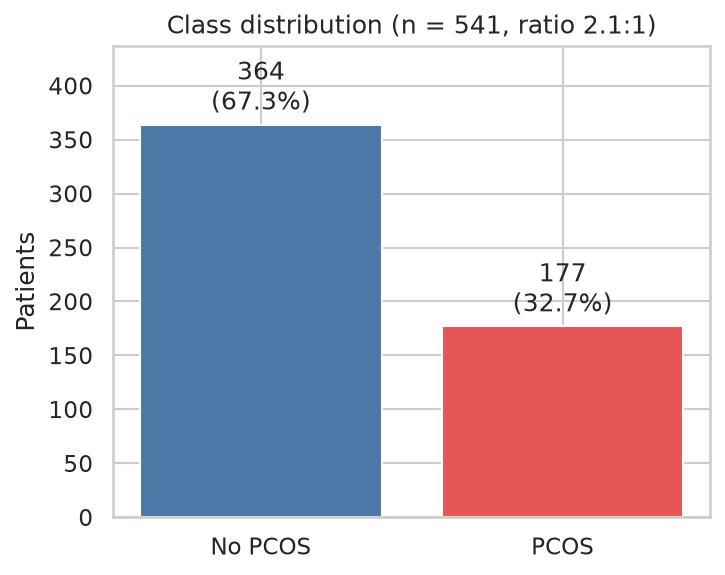

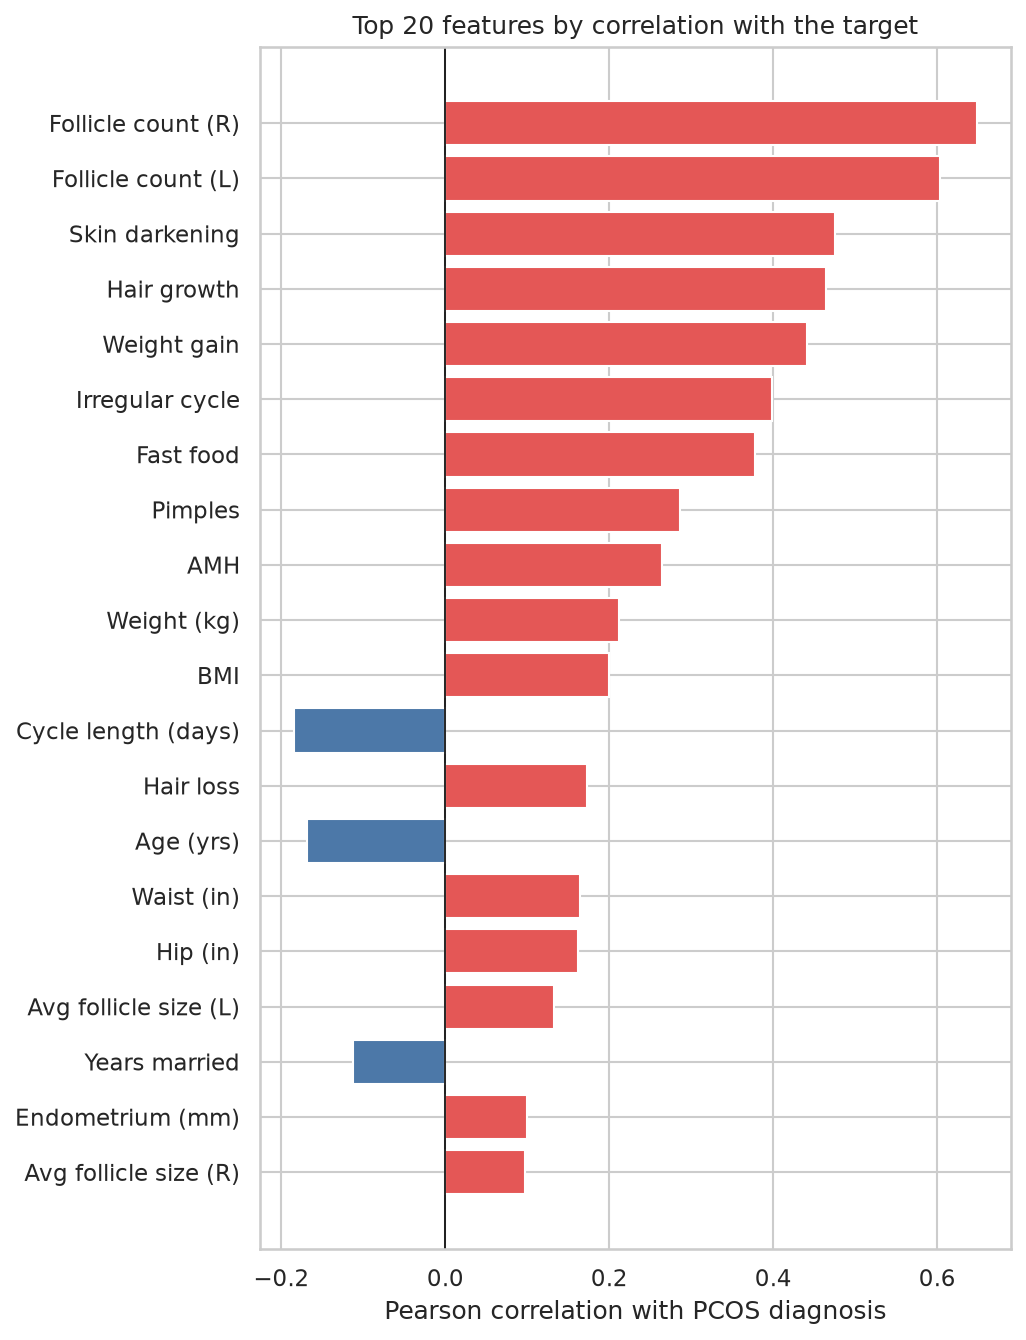

In [5]:
from IPython.display import Image, display
display(Image(str(config.FIGURES_DIR / "01_class_balance.png")))
display(Image(str(config.FIGURES_DIR / "03_target_correlations.png")))


In [6]:
stats = eda.summary_statistics(df)
print("Largest standardised differences between the two groups (Cohen's d):")
stats.head(12)


Largest standardised differences between the two groups (Cohen's d):


,feature,mean_no_pcos,mean_pcos,std_no_pcos,std_pcos,cohens_d
0,Follicle count (R),4.637,10.763,2.926,4.166,1.702
1,Follicle count (L),4.352,9.785,2.814,4.309,1.493
2,Skin darkening,0.154,0.621,0.361,0.486,1.091
3,Hair growth,0.129,0.571,0.336,0.496,1.042
4,Weight gain,0.228,0.684,0.420,0.466,1.026
5,Fast food,0.383,0.785,0.487,0.412,0.893
6,Irregular cycle,0.154,0.534,0.361,0.500,0.871
7,Pimples,0.390,0.695,0.488,0.462,0.641
8,AMH,4.541,7.514,4.291,6.451,0.543
9,Weight (kg),58.009,62.986,10.047,12.175,0.446


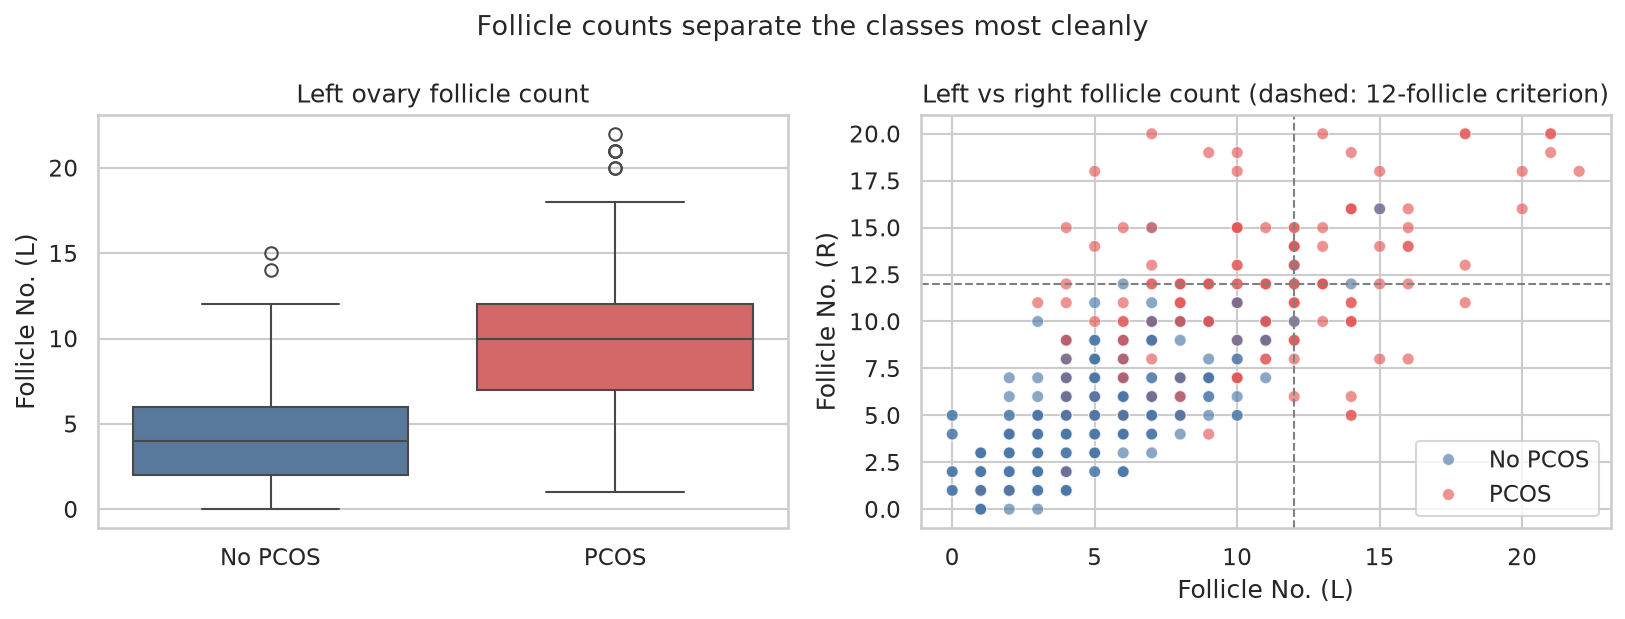

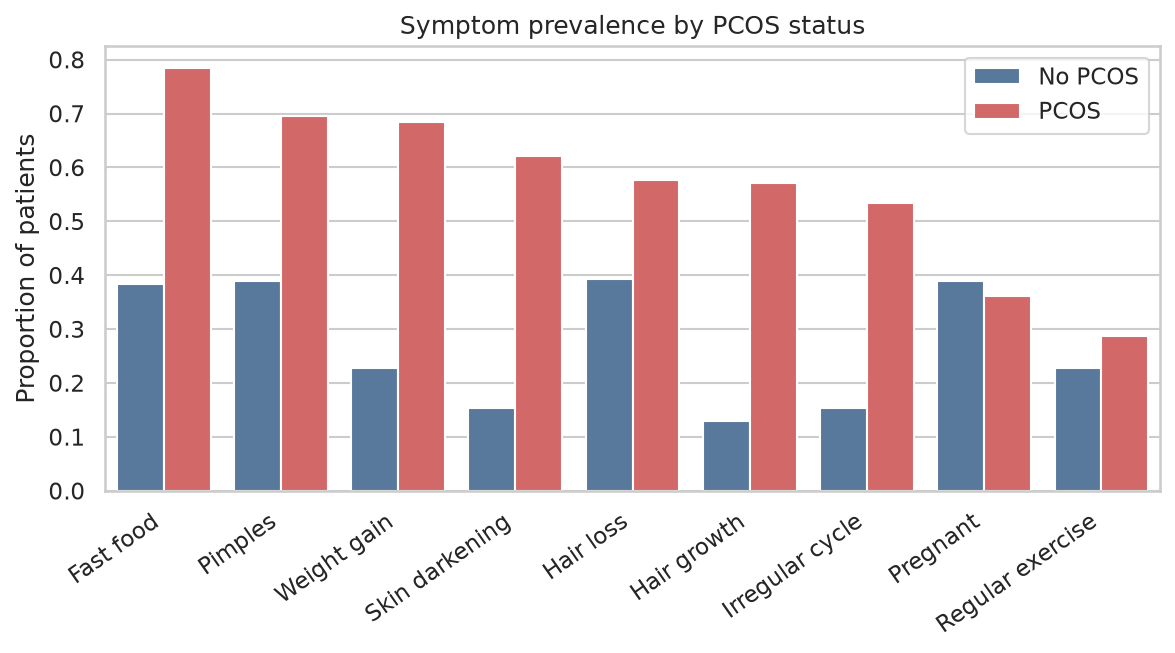

In [7]:
display(Image(str(config.FIGURES_DIR / "07_follicle_separation.png")))
display(Image(str(config.FIGURES_DIR / "06_symptom_prevalence.png")))


**Reading the EDA.** Follicle counts dominate everything else (Cohen's *d* ≈ 1.5–1.7,
a very large effect). This is expected and reassuring — follicle count is one leg of the
Rotterdam diagnostic criteria, so a model that leans on it is behaving sensibly rather
than exploiting an artefact.

The next tier is the self-reported symptom cluster: skin darkening, hair growth and
weight gain, all around *d* ≈ 1.0. The hormone panels (FSH, LH, TSH, prolactin) are
much weaker individually than their clinical prominence would suggest.

One caveat worth flagging in the write-up: `Cycle length(days)` has a median of 5 and a
range of 2–12. Those are not menstrual *cycle* intervals (which would be ~28 days) —
the column is almost certainly recording the duration of bleeding. The Kaggle
documentation does not clarify this, so we report it as-is and note the ambiguity.


## 3. Train / test split — done first, on purpose

The split happens **before** any feature selection, scaling or resampling decision.
The test set is then untouched until Section 6.


In [8]:
X_train, X_test, y_train, y_test = evaluate.make_splits(X, y)
print(f"Train: {X_train.shape[0]} rows ({(y_train==1).sum()} PCOS)")
print(f"Test : {X_test.shape[0]} rows ({(y_test==1).sum()} PCOS)")


Train: 432 rows (141 PCOS)
Test : 109 rows (36 PCOS)


## 4. Feature selection

Three strategies are compared against an all-features baseline:

* **Correlation** — keep features correlated with the target above a threshold, then drop
  one of every pair of mutually redundant features.
* **Chi-Square** — top-*k* by χ² statistic (min-max scaled first, since χ² needs
  non-negative inputs).
* **RFE** — Recursive Feature Elimination driven by logistic regression.

Each is a scikit-learn transformer, so selection is refitted per fold.


In [9]:
X_prep = models.build_preprocessor(X_train).fit_transform(X_train, y_train)

for name in ("correlation", "chi2", "rfe"):
    sel = features.build_selector(name, k=15).fit(X_prep, y_train)
    print(f"\n{name.upper()} kept {len(sel.selected_features_)} features:")
    for f in sel.selected_features_:
        print("   ", config.pretty(str(f)))



CORRELATION kept 20 features:
    Follicle count (R)
    Follicle count (L)
    Skin darkening
    Hair growth
    Weight gain
    Irregular cycle
    Fast food
    AMH
    Pimples
    Weight (kg)
    Waist (in)
    Cycle length (days)
    Hair loss
    Age (yrs)
    Avg follicle size (L)
    Avg follicle size (R)
    Years married
    Endometrium (mm)
    Pulse rate (bpm)
    LH

CHI2 kept 15 features:
    Weight (kg)
    BMI
    Cycle length (days)
    Waist (in)
    AMH
    Follicle count (L)
    Follicle count (R)
    Weight gain
    Hair growth
    Skin darkening
    Hair loss
    Pimples
    Fast food
    Regular exercise
    Irregular cycle



RFE kept 15 features:
    Years married
    Follicle count (L)
    Follicle count (R)
    Blood Group_11
    Blood Group_12
    Blood Group_13
    Blood Group_14
    Blood Group_15
    Blood Group_17
    Weight gain
    Hair growth
    Skin darkening
    Pimples
    Fast food
    Irregular cycle


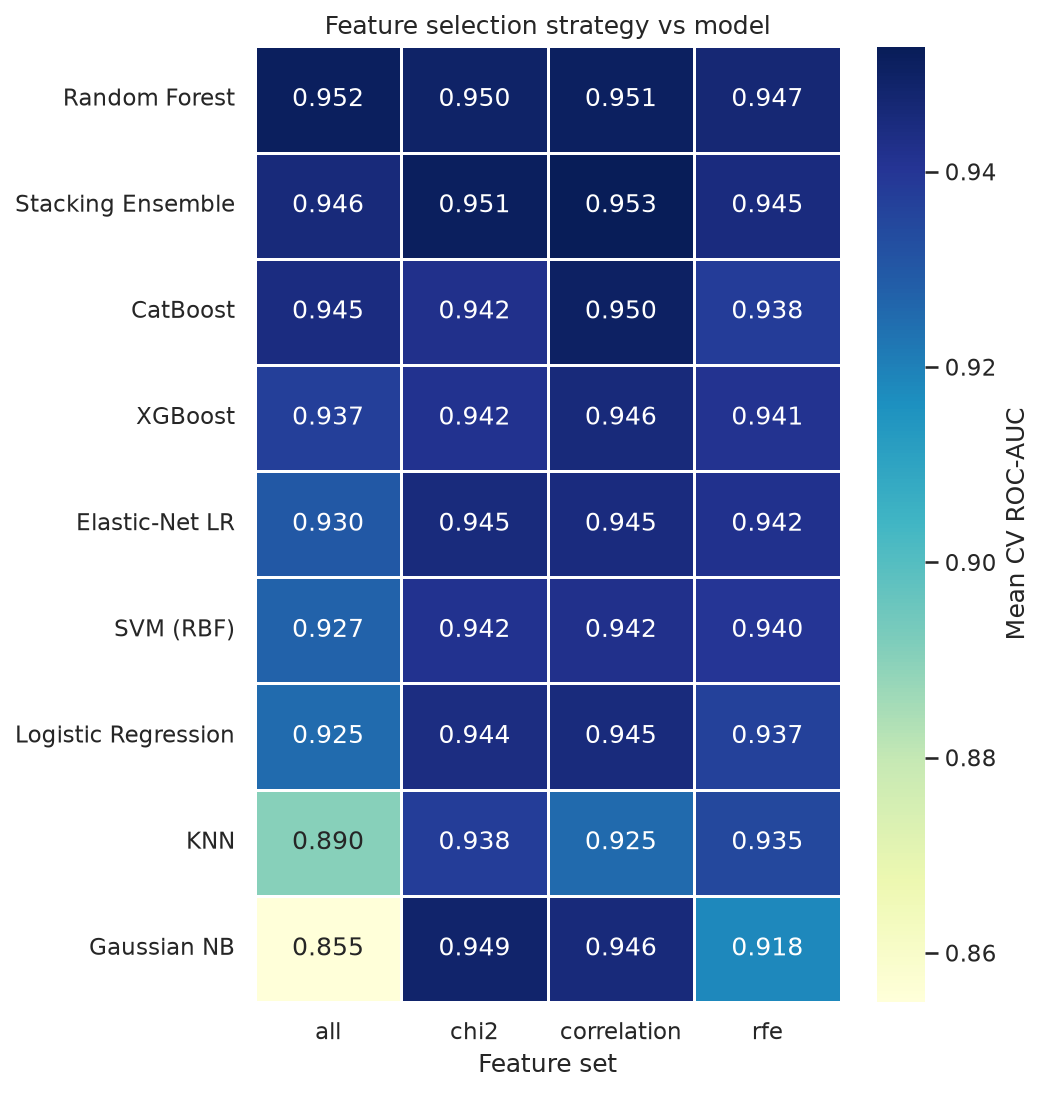

               mean     std     max
feature_set                        
all          0.9230  0.0312  0.9515
chi2         0.9447  0.0044  0.9513
correlation  0.9449  0.0081  0.9528
rfe          0.9380  0.0083  0.9468

Best feature set: correlation


In [10]:
feature_comparison = evaluate.compare_feature_sets(
    models.build_all_models, X_train, y_train, k_features=15, repeats=1
)
plots.plot_feature_set_comparison(feature_comparison)
display(Image(str(config.FIGURES_DIR / "09_feature_set_comparison.png")))

summary = feature_comparison.groupby("feature_set")["roc_auc"].agg(["mean", "std", "max"])
best_set = summary["mean"].idxmax()
print(summary.round(4))
print("\nBest feature set:", best_set)


The differences between feature sets are small — a couple of thousandths of AUC, well
inside the fold-to-fold noise. That is itself a result: on this dataset, *which* selection
method you use matters far less than whether you apply it correctly. The reduced sets are
still preferable because 15 features are easier to collect in a clinic than 41, and fewer
parameters means less room to overfit 432 training rows.


## 5. Model comparison under repeated stratified cross-validation

Five models, each wrapped in the full pipeline:

```
impute → scale/encode → select features → SMOTE → classifier
```

Cross-validation is **repeated** (10 folds × 3 repeats). With only ~430 training rows a
single 10-fold run swings by several points depending on the shuffle, so reporting one
run would be reporting noise.


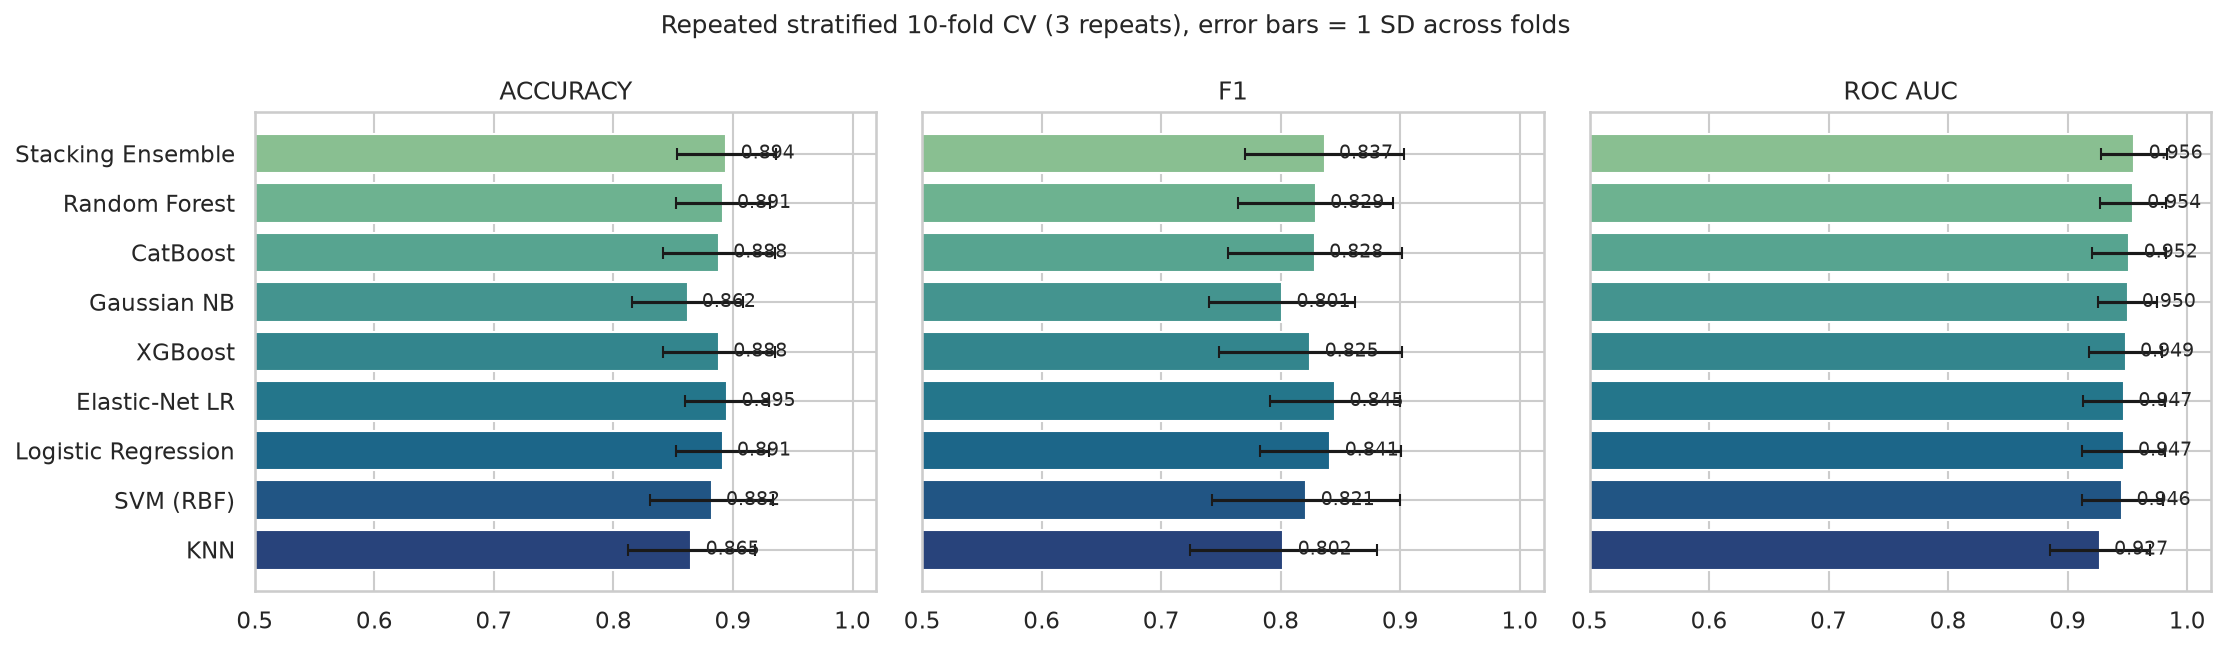

Best model by CV ROC-AUC: Stacking Ensemble


,model,accuracy,accuracy_std,precision,recall,f1,roc_auc,roc_auc_std
0,Stacking Ensemble,0.8944,0.0415,0.8452,0.8367,0.8367,0.9557,0.0275
1,Random Forest,0.8913,0.0393,0.8533,0.8152,0.8293,0.9544,0.0274
2,CatBoost,0.8882,0.0466,0.8347,0.8297,0.8285,0.9516,0.0310
3,Gaussian NB,0.8619,0.0468,0.7685,0.8462,0.8011,0.9500,0.0246
4,XGBoost,0.8882,0.0466,0.8457,0.8130,0.8247,0.9485,0.0306
5,Elastic-Net LR,0.8951,0.0350,0.8150,0.8841,0.8454,0.9471,0.0344
6,Logistic Regression,0.8913,0.0390,0.8056,0.8865,0.8415,0.9468,0.0346
7,SVM (RBF),0.8821,0.0518,0.8203,0.8344,0.8213,0.9456,0.0340
8,KNN,0.8651,0.0529,0.7778,0.8394,0.8021,0.9268,0.0418


In [11]:
cv_models = models.build_all_models(X_train, selector=best_set, k_features=15)
cv_results = evaluate.cross_validate_models(cv_models, X_train, y_train)

plots.plot_cv_comparison(cv_results)
display(Image(str(config.FIGURES_DIR / "08_cv_model_comparison.png")))

best_model_name = cv_results.iloc[0]["model"]
print("Best model by CV ROC-AUC:", best_model_name)

cols = ["model", "accuracy", "accuracy_std", "precision", "recall", "f1", "roc_auc", "roc_auc_std"]
cv_results[cols].round(4)


Look at the standard deviations before the means. The models sit within roughly one
standard deviation of each other on ROC-AUC. Rather than assert they are tied, the next
two sections test it.


### 5b. Is the ranking real? Paired significance tests

Every model is scored on **identical folds**, so the per-fold difference isolates the
model rather than the split. Two separate questions get two separate columns:

* `statistically_sep` — did a paired t-test detect *any* consistent difference?
* `practically_sep` — is the gap big enough to matter (>= 0.02 AUC)?

Conflating these is a standard way to over-claim.


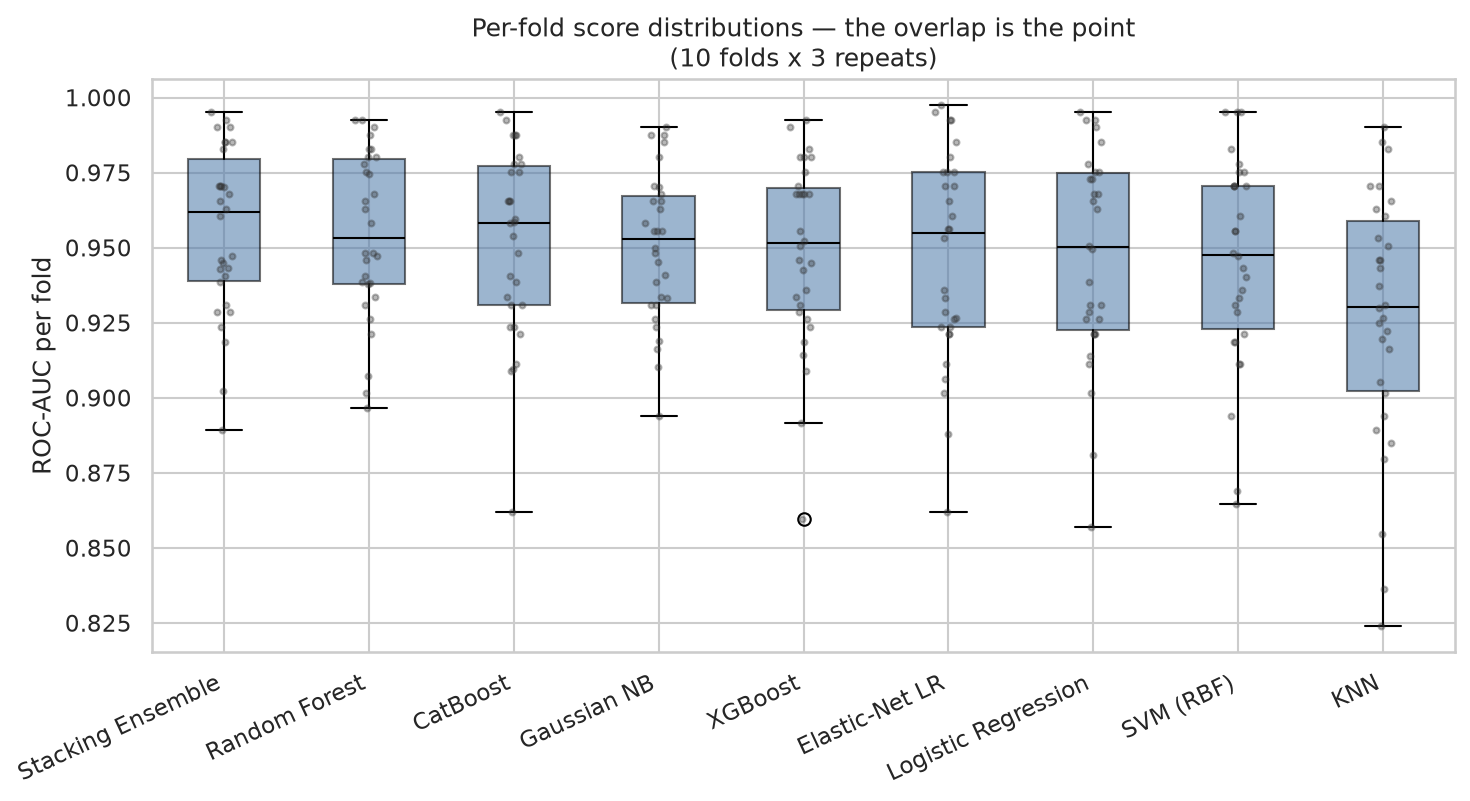

,model,mean_score,std,delta_vs_best,p_value,statistically_sep,practically_sep
0,Stacking Ensemble,0.9557,0.0280,0.0000,NaN,— (reference),— (reference)
1,Random Forest,0.9544,0.0279,-0.0012,0.3887,no,no
2,CatBoost,0.9516,0.0315,-0.0041,0.0470,yes,no
3,Gaussian NB,0.9500,0.0250,-0.0057,0.1458,no,no
4,XGBoost,0.9485,0.0311,-0.0071,0.0020,yes,no
5,Elastic-Net LR,0.9471,0.0350,-0.0086,0.0053,yes,no
6,Logistic Regression,0.9468,0.0352,-0.0089,0.0023,yes,no
7,SVM (RBF),0.9456,0.0346,-0.0101,0.0001,yes,no
8,KNN,0.9268,0.0425,-0.0289,0.0000,yes,yes


In [12]:
fold_scores = calibration.paired_fold_scores(cv_models, X_train, y_train)
significance = calibration.significance_against_best(fold_scores)
calibration.plot_significance(fold_scores)
display(Image(str(config.FIGURES_DIR / "20_significance_boxplot.png")))
significance.round(4)


**Zero of eight** models differ from the best by a practically meaningful margin. The
largest gap in the table is ~0.012 AUC, against a fold-to-fold standard deviation of
~0.030 — six times larger.

The two columns disagree, and that is the lesson. With 30 folds a paired test flags
XGBoost's 0.009 AUC deficit as "significant" (p = 0.003), but no clinical decision turns
on 0.009 AUC. Statistical separability is not the same as mattering.

Two consequences for the report:

* **The stacking ensemble buys nothing.** Papers 4 and 5 both crown a stacking classifier;
  here it lands 0.001 AUC below a plain Random Forest, while costing far more to train
  and explain.
* **Gaussian Naive Bayes is competitive** — no hyperparameters, a famously wrong
  independence assumption, and still statistically tied with the best. Strong evidence
  that this dataset's signal is simple and additive.

*Caveat:* repeated-CV folds overlap, so scores are not independent and the paired t-test
is optimistic. Large p-values (evidence of no difference) are trustworthy; small ones are
suggestive only. Fortunately that is the direction this argument needs.


### 5c. Calibration — do the predicted probabilities mean anything?

ROC-AUC measures only *ordering*. A model can rank patients perfectly and still claim 0.8
for cases that turn out positive 60% of the time. Every metric in the five reviewed papers
is blind to this, and it is precisely what matters when a probability sets a screening
threshold.

* **Brier score** — a proper scoring rule, minimised only by honest probabilities.
* **ECE** — mean gap between claimed confidence and observed frequency.


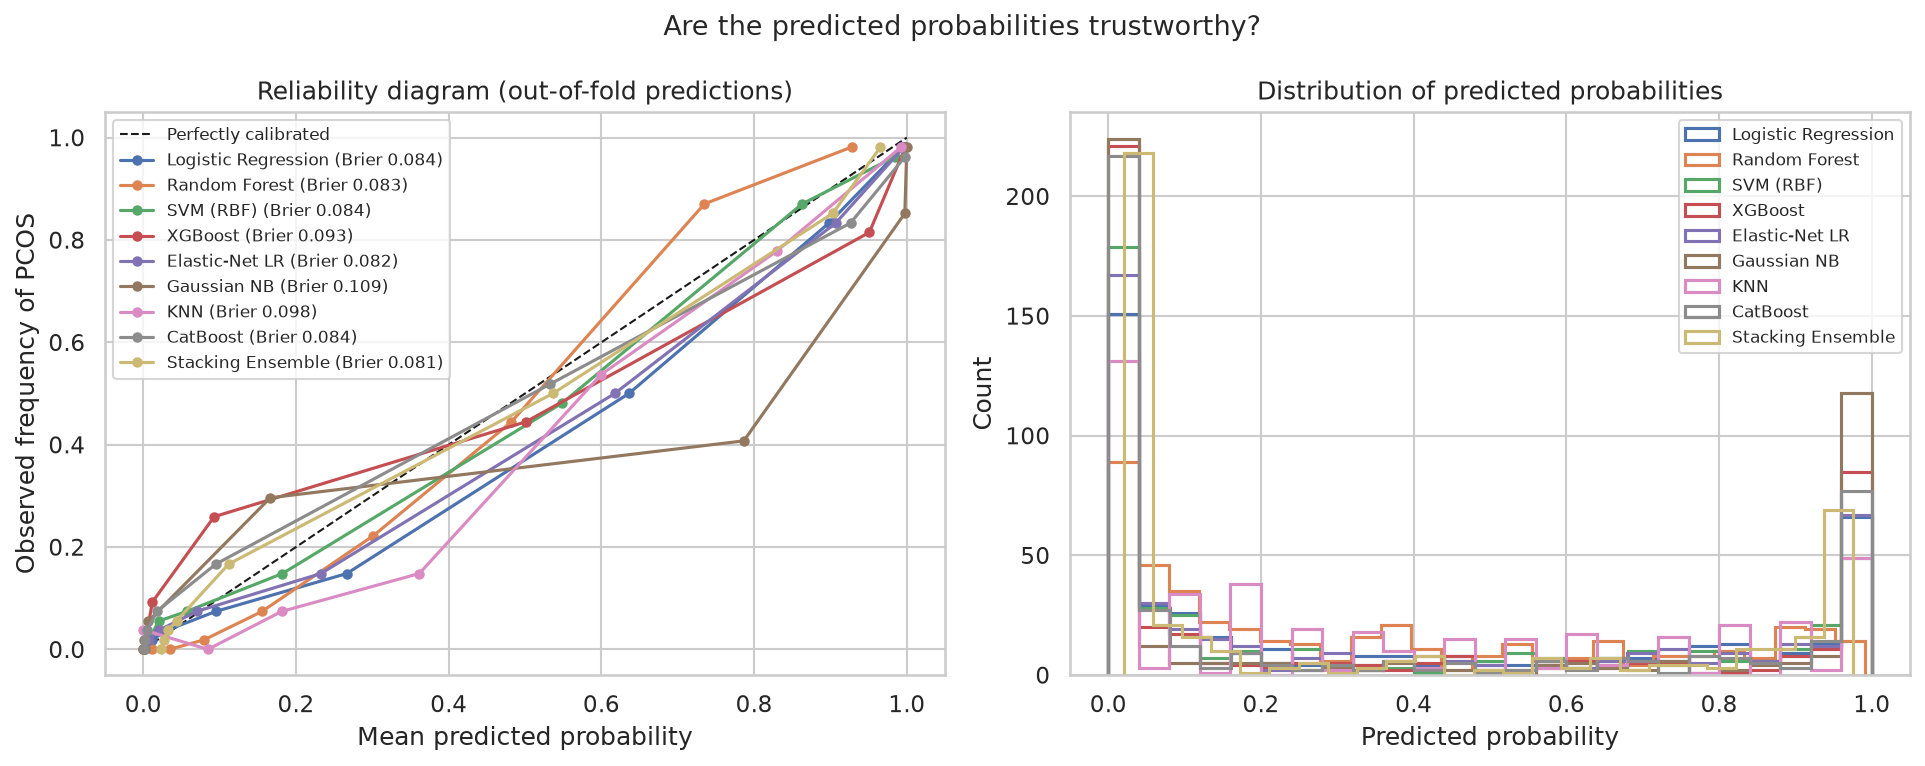

,model,brier,log_loss,ece,roc_auc
0,Stacking Ensemble,0.0808,0.2724,0.0328,0.9496
1,Elastic-Net LR,0.0817,0.2819,0.0482,0.9454
2,Random Forest,0.0827,0.2758,0.0605,0.9559
3,CatBoost,0.0838,0.2985,0.0477,0.9484
4,Logistic Regression,0.0839,0.2846,0.0561,0.9450
5,SVM (RBF),0.0839,0.2989,0.0343,0.9425
6,XGBoost,0.0932,0.3313,0.0649,0.9453
7,KNN,0.0983,0.7656,0.0718,0.9284
8,Gaussian NB,0.1090,0.4406,0.1003,0.9510


In [13]:
calibration_results = calibration.compare_calibration(cv_models, X_train, y_train, folds=5)
calibration.plot_calibration_curves(cv_models, X_train, y_train, folds=5)
display(Image(str(config.FIGURES_DIR / "19_calibration_curves.png")))
calibration_results.round(4)


This ranking is **not** the ROC-AUC ranking. Gaussian NB is statistically tied with the
best on AUC yet is by far the worst-calibrated — its rankings are fine but its
probabilities are near-useless. XGBoost is second-worst. This is exactly the kind of
difference that should decide between tied models.


In [14]:
# Does explicit calibration help? Not always.
base = models.classifier_by_name(best_model_name)
effect = calibration.calibration_effect(
    models.build_pipeline(X_train, base, selector=best_set, k_features=15),
    models.build_calibrated(X_train, base, selector=best_set, k_features=15),
    X_train, y_train,
)
effect.round(4)


,variant,brier,log_loss,ece,roc_auc
0,uncalibrated,0.0808,0.2724,0.0328,0.9496
1,calibrated,0.0799,0.4226,0.0432,0.9478
2,change,-0.0009,0.1502,0.0104,-0.0018


**A negative result worth reporting.** Isotonic calibration did not help: Brier improves by
a rounding error while log loss rises sharply, ECE gets *worse*, and AUC dips.

Two things are happening. Isotonic regression is non-parametric and needs more than 432
rows to fit a stable mapping, so it overfits the calibration folds. It also pins
probabilities hard at 0 and 1, which log loss punishes severely on the cases it gets
wrong.

Calibration is not free, and on a dataset this size the textbook fix can make the
probabilities less trustworthy rather than more.


## 6. Class imbalance: measure it, don't assume it

None of the five reviewed papers state how they handled the 2:1 imbalance. Rather than
assume SMOTE helps, all three options are compared on the same held-out data.


In [15]:
from sklearn.ensemble import RandomForestClassifier

def rf(**kwargs):
    return RandomForestClassifier(n_estimators=400, min_samples_leaf=2,
                                  random_state=config.RANDOM_STATE, n_jobs=-1, **kwargs)

ablation = evaluate.balance_ablation(X_train, y_train, X_test, y_test, rf)
ablation[["strategy", "accuracy", "precision", "recall", "f1", "specificity", "roc_auc"]].round(4)


,strategy,accuracy,precision,recall,f1,specificity,roc_auc
0,no balancing,0.9083,0.9062,0.8056,0.8529,0.9589,0.9346
1,class weighting,0.8991,0.8378,0.8611,0.8493,0.9178,0.9277
2,SMOTE,0.8991,0.8571,0.8333,0.8451,0.9315,0.9319


The effect is real but modest: SMOTE buys a few points of recall — i.e. it catches PCOS
cases the unbalanced model misses — at essentially no cost in specificity. For a screening
tool that trade is worth taking, since a missed diagnosis is worse than a false alarm that
gets resolved by a confirmatory ultrasound.


## 7. Held-out test set

Everything above used only the training split. This is the first and only look at the
test set.


In [16]:
test_models = models.build_all_models(X_train, selector=best_set, k_features=15)
test_results = evaluate.evaluate_on_test(test_models, X_train, y_train, X_test, y_test)
test_results[["model", "accuracy", "precision", "recall", "f1", "specificity", "roc_auc"]].round(4)


,model,accuracy,precision,recall,f1,specificity,roc_auc
0,CatBoost,0.9358,0.9143,0.8889,0.9014,0.9589,0.9585
1,XGBoost,0.9266,0.9118,0.8611,0.8857,0.9589,0.9543
2,Elastic-Net LR,0.9174,0.8649,0.8889,0.8767,0.9315,0.9494
3,Logistic Regression,0.9083,0.8421,0.8889,0.8649,0.9178,0.9482
4,Gaussian NB,0.9083,0.8250,0.9167,0.8684,0.9041,0.9467
5,Stacking Ensemble,0.9266,0.9375,0.8333,0.8824,0.9726,0.9452
6,Random Forest,0.9174,0.9091,0.8333,0.8696,0.9589,0.9452
7,SVM (RBF),0.8991,0.8788,0.8056,0.8406,0.9452,0.9441
8,KNN,0.8532,0.7778,0.7778,0.7778,0.8904,0.9399


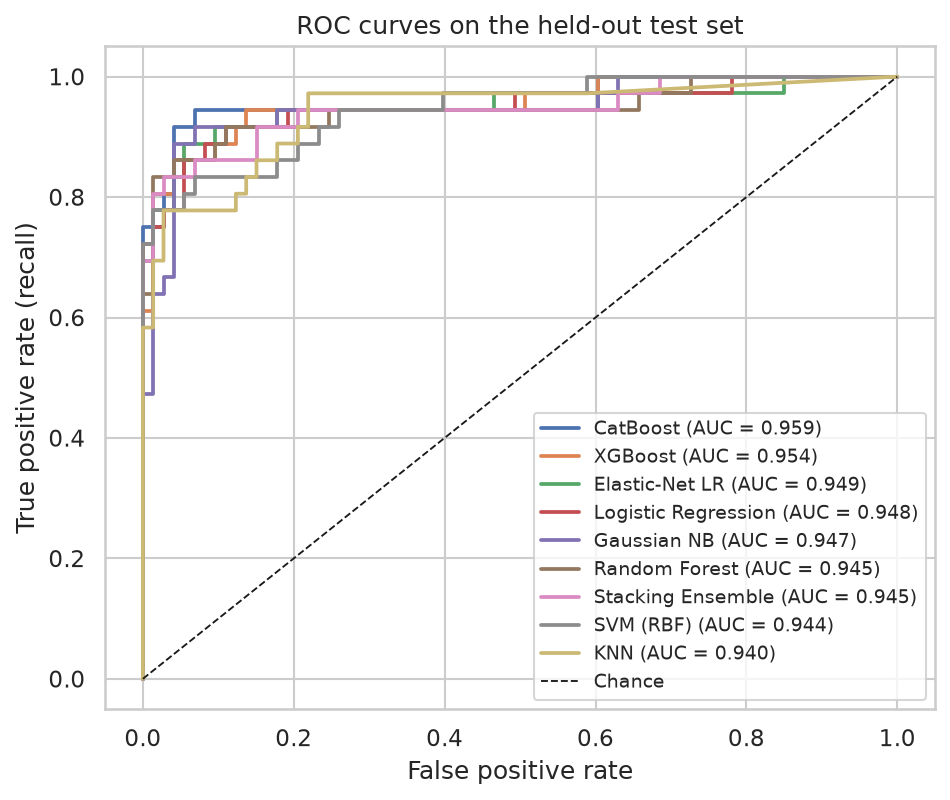

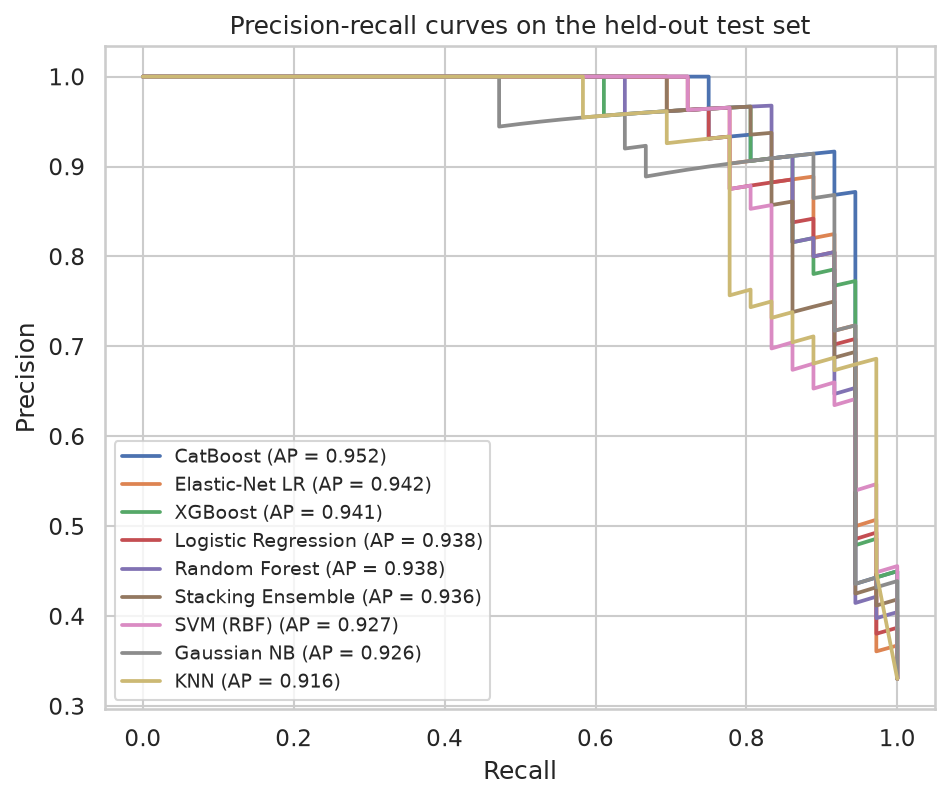

In [17]:
curves = evaluate.curve_data(test_models, X_test, y_test)
plots.plot_roc_curves(curves)
plots.plot_pr_curves(curves)
display(Image(str(config.FIGURES_DIR / "10_roc_curves.png")))
display(Image(str(config.FIGURES_DIR / "11_pr_curves.png")))


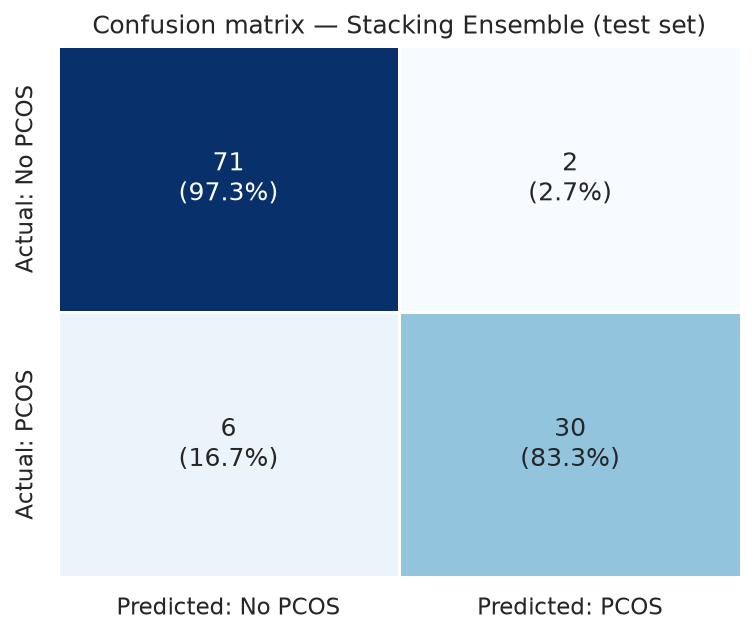

Selected model: Stacking Ensemble


In [18]:
best_pipeline = test_models[best_model_name]
y_pred = best_pipeline.predict(X_test)

plots.plot_confusion_matrix(y_test, y_pred, best_model_name)
display(Image(str(config.FIGURES_DIR / "12_confusion_matrix.png")))
print("Selected model:", best_model_name)


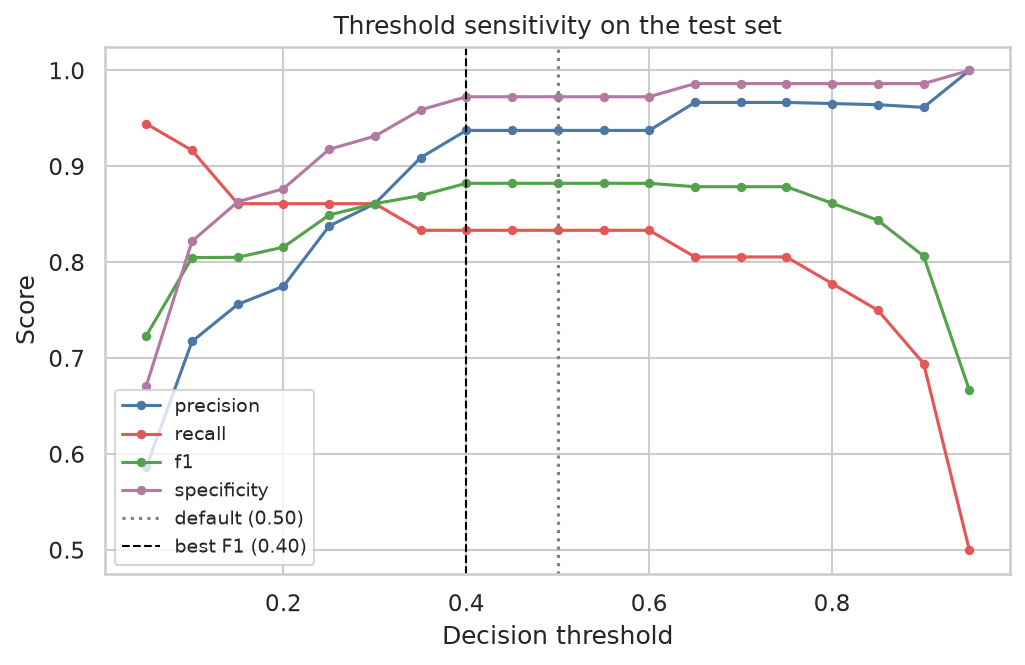

,threshold,accuracy,precision,recall,f1,true_negatives,false_positives,false_negatives,true_positives,specificity
0,0.05,0.761468,0.586207,0.944444,0.723404,49,24,2,34,0.671233
1,0.10,0.853211,0.717391,0.916667,0.804878,60,13,3,33,0.821918
2,0.15,0.862385,0.756098,0.861111,0.805195,63,10,5,31,0.863014
3,0.20,0.871560,0.775000,0.861111,0.815789,64,9,5,31,0.876712
4,0.25,0.899083,0.837838,0.861111,0.849315,67,6,5,31,0.917808
5,0.30,0.908257,0.861111,0.861111,0.861111,68,5,5,31,0.931507
6,0.35,0.917431,0.909091,0.833333,0.869565,70,3,6,30,0.958904
7,0.40,0.926606,0.937500,0.833333,0.882353,71,2,6,30,0.972603
8,0.45,0.926606,0.937500,0.833333,0.882353,71,2,6,30,0.972603
9,0.50,0.926606,0.937500,0.833333,0.882353,71,2,6,30,0.972603


In [19]:
sweep = evaluate.threshold_sweep(best_pipeline, X_test, y_test)
plots.plot_threshold_sweep(sweep)
display(Image(str(config.FIGURES_DIR / "14_threshold_sweep.png")))
sweep.head(10)


The default 0.5 threshold is a convention, not a clinical decision. Lowering it trades
precision for recall — appropriate for a screening tool whose false positives get filtered
by a follow-up ultrasound, while false negatives walk out of the clinic undiagnosed.


## 8. The leakage experiment

This is the section that addresses the gap analysis directly.

Papers 4 and 5 report 98.9–99.3% accuracy on this same 541-row dataset. Our correctly
validated pipeline reaches noticeably less. Rather than hand-wave about why, we **measure**
the difference by running the same classifier under two protocols:

| Protocol | SMOTE + feature selection | What goes wrong |
|---|---|---|
| **Correct** | Inside the pipeline, refit per fold | Nothing — validation folds stay unseen |
| **Leaky** | Once, on the whole dataset, before CV | Synthetic minority rows interpolated from training patients land in the validation fold; the selector has already read every label |

Both use identical folds, identical data and an identical model. The only difference is
*where* the resampling happens.


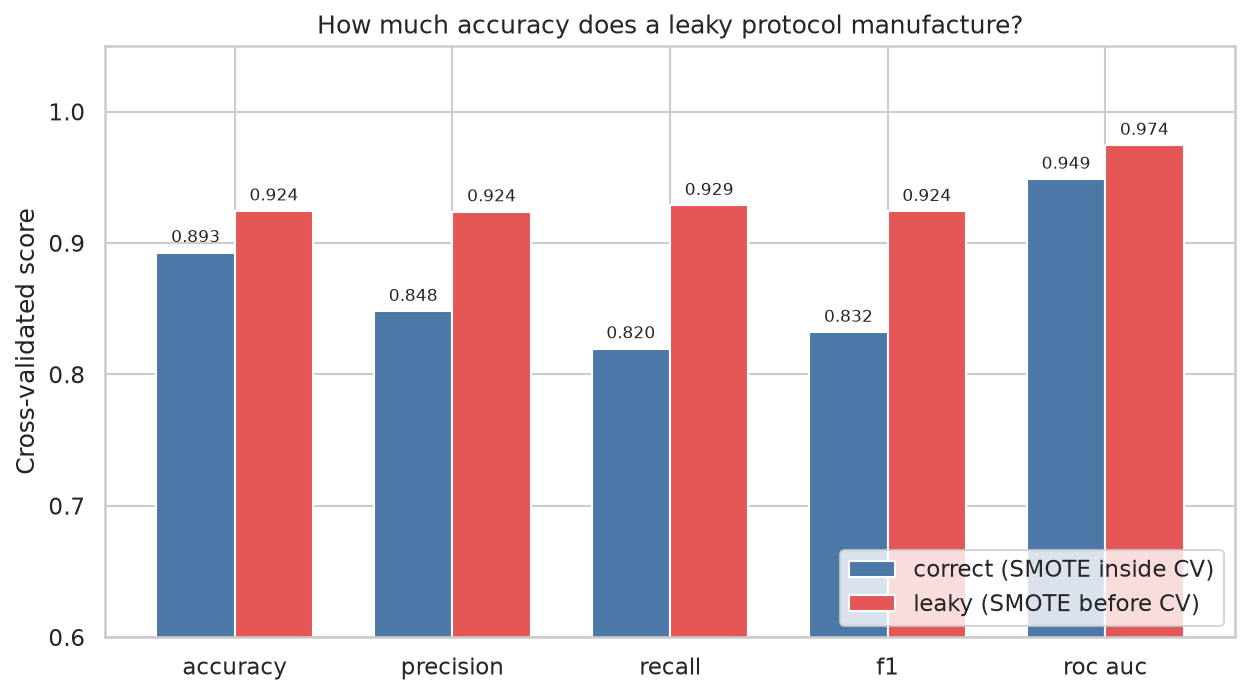

,protocol,accuracy,balanced_accuracy,precision,recall,f1,roc_auc
0,correct (SMOTE inside CV),0.8928,0.8741,0.8480,0.8196,0.8321,0.9486
1,leaky (SMOTE before CV),0.9245,0.9246,0.9238,0.9287,0.9241,0.9745
2,inflation (leaky - correct),0.0317,0.0505,0.0758,0.1091,0.0920,0.0259


In [20]:
leakage = evaluate.leakage_experiment(X, y, rf)
plots.plot_leakage_experiment(leakage)
display(Image(str(config.FIGURES_DIR / "13_leakage_experiment.png")))
leakage.round(4)


**This is the headline finding of the project.** Simply moving SMOTE from inside the
cross-validation loop to outside it manufactures several points of accuracy and a much
larger jump in recall and F1 — without changing the model, the data, or the folds by
a single row.

That does not prove the reviewed papers made this mistake. Most of them do not describe
their protocol in enough detail to tell, which is precisely the problem. What it does show
is that a 98–99% headline on 541 records is *reachable* through methodology alone, so such
numbers cannot be taken at face value without a stated protocol.


## 9. Explainable AI with SHAP

Accuracy tells a clinician nothing actionable. SHAP decomposes each individual prediction
into signed per-feature contributions, answering both *what does the model rely on overall*
and *why this patient*.


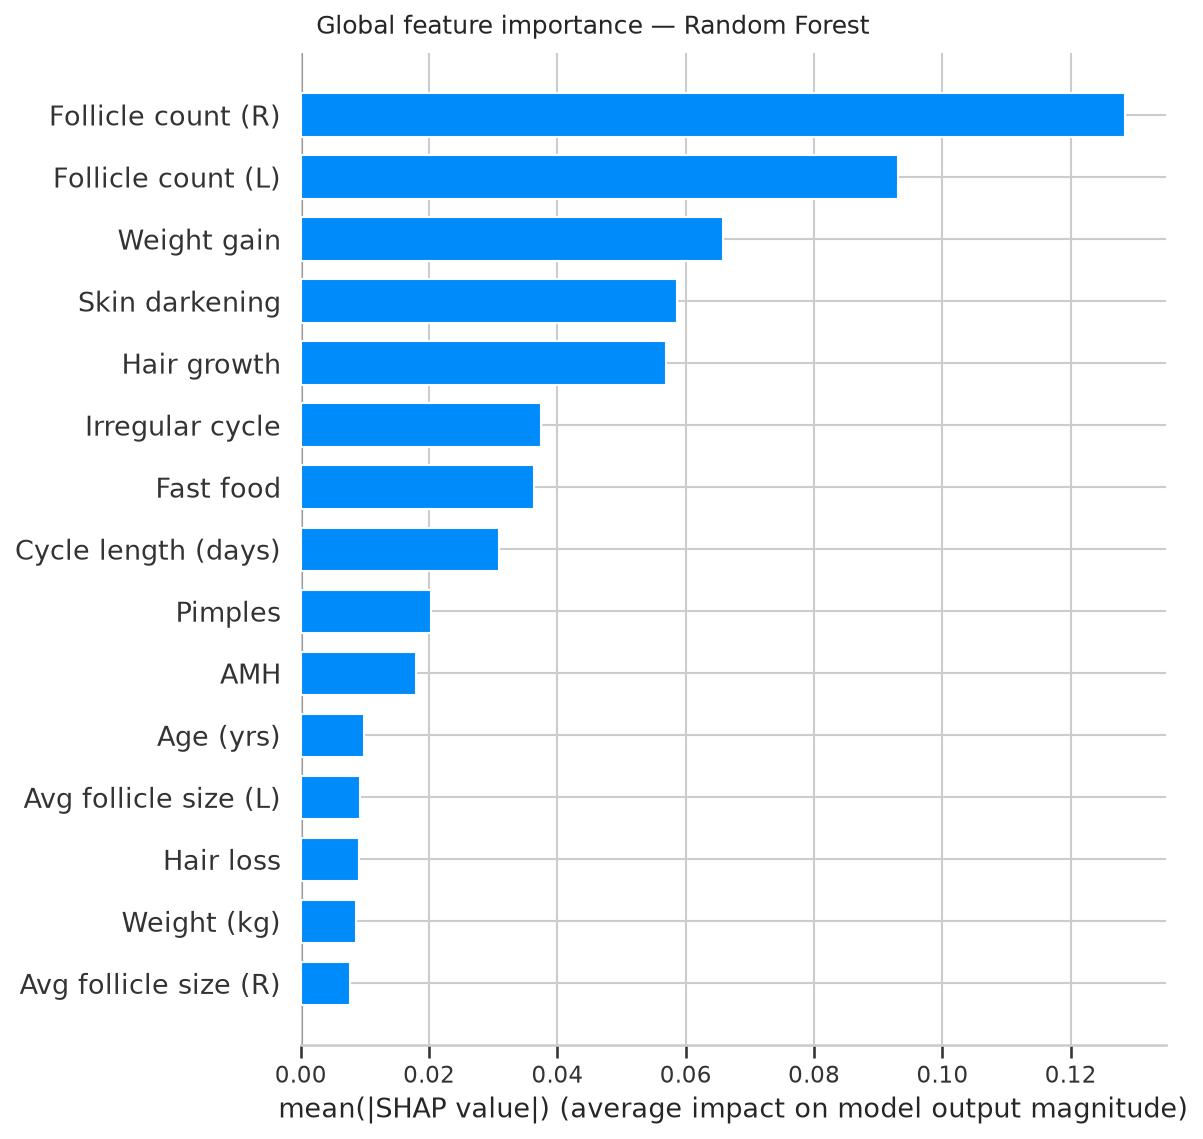

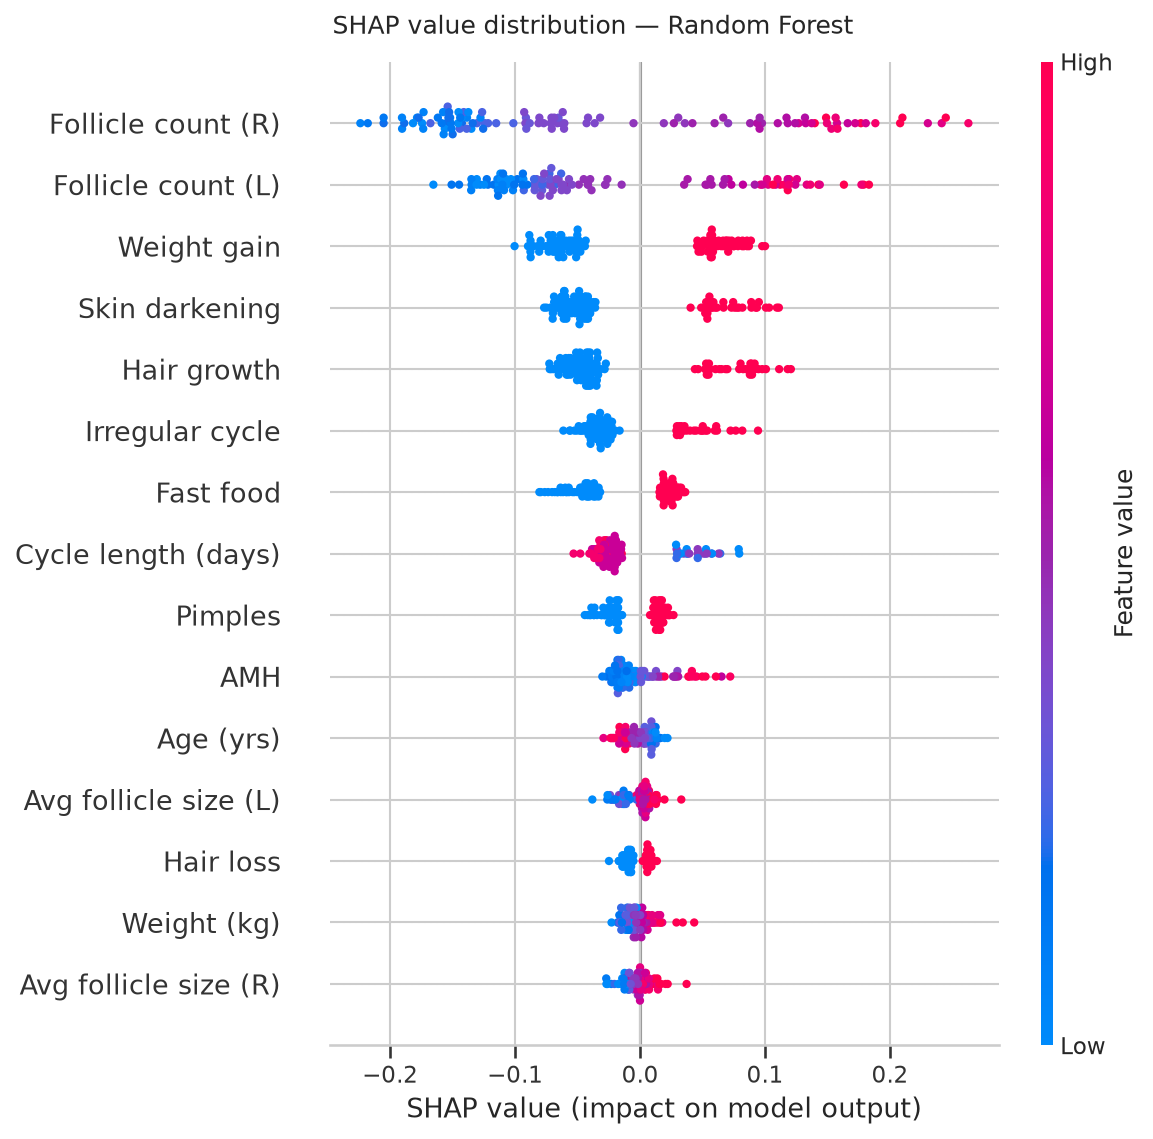

In [21]:
explain_name = "Random Forest"
explain_pipeline = test_models[explain_name]

shap_values, shap_data = explain.shap_values_for(explain_pipeline, X_test)
explain.plot_global_importance(shap_values, shap_data, explain_name)
explain.plot_beeswarm(shap_values, shap_data, explain_name)

display(Image(str(config.FIGURES_DIR / "16_shap_global_importance.png")))
display(Image(str(config.FIGURES_DIR / "17_shap_beeswarm.png")))


In [22]:
importance = explain.importance_table(shap_values, shap_data)
importance.head(12).round(4)


,feature,mean_abs_shap,value_shap_corr,higher_value_means
0,Follicle count (R),0.1284,0.9156,more likely PCOS
1,Follicle count (L),0.0930,0.9117,more likely PCOS
2,Weight gain,0.0658,0.9795,more likely PCOS
3,Skin darkening,0.0587,0.9725,more likely PCOS
4,Hair growth,0.0570,0.9691,more likely PCOS
5,Irregular cycle,0.0375,0.9503,more likely PCOS
6,Fast food,0.0364,0.9643,more likely PCOS
7,Cycle length (days),0.0310,-0.7387,less likely PCOS
8,Pimples,0.0202,0.9571,more likely PCOS
9,AMH,0.0179,0.8474,more likely PCOS


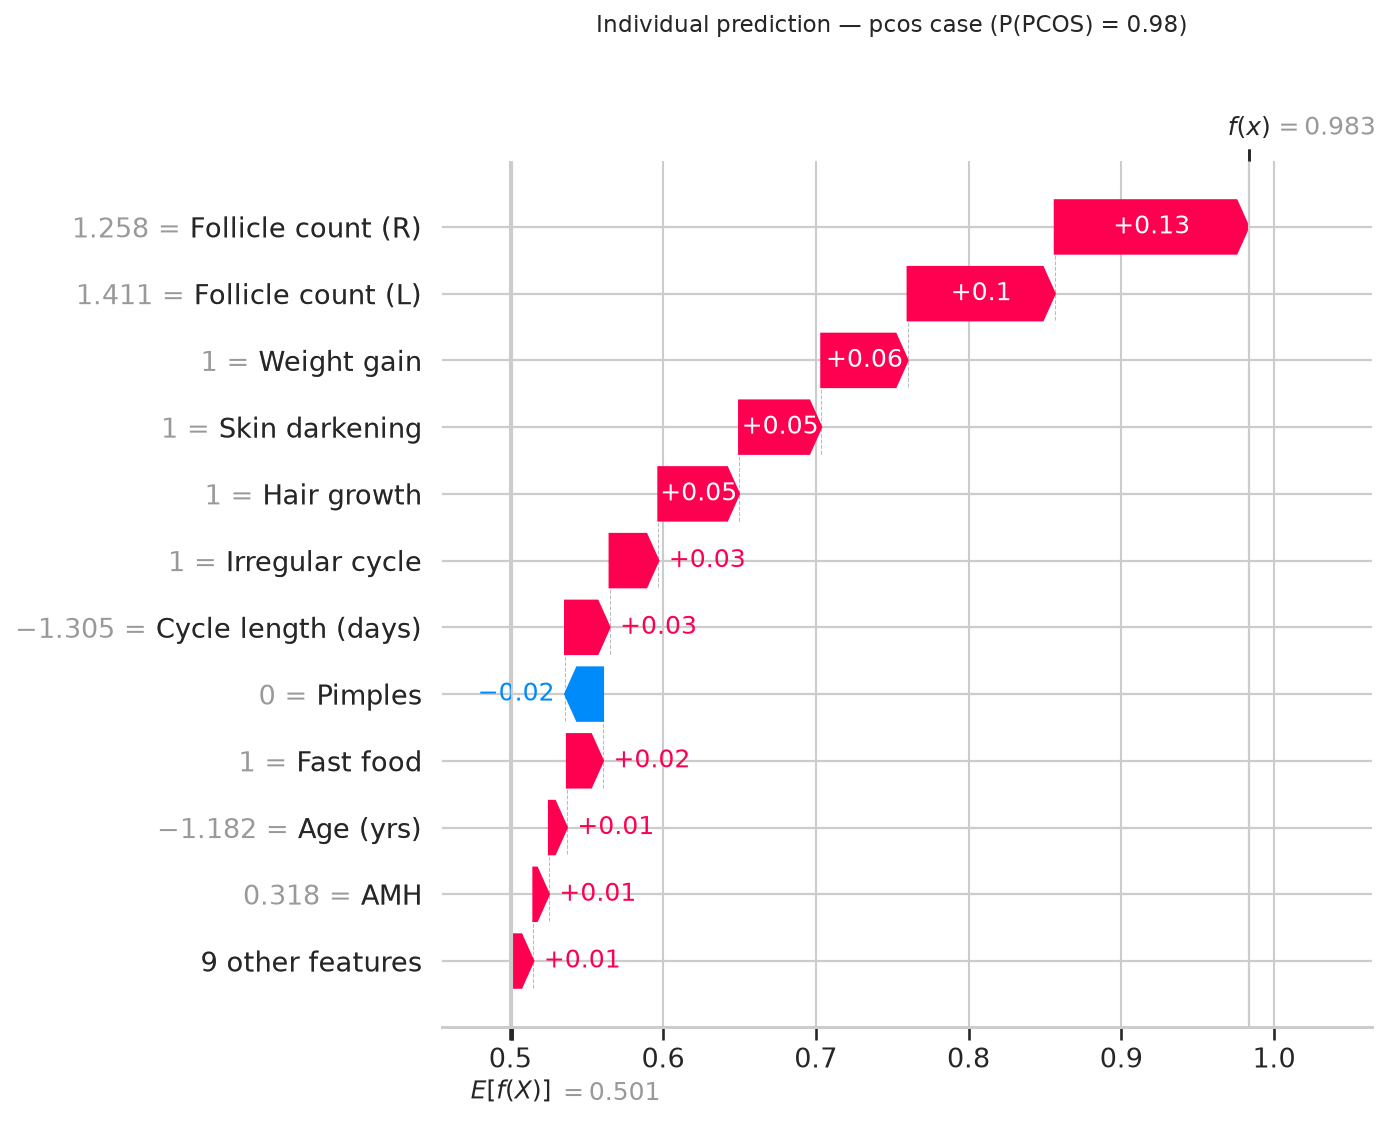

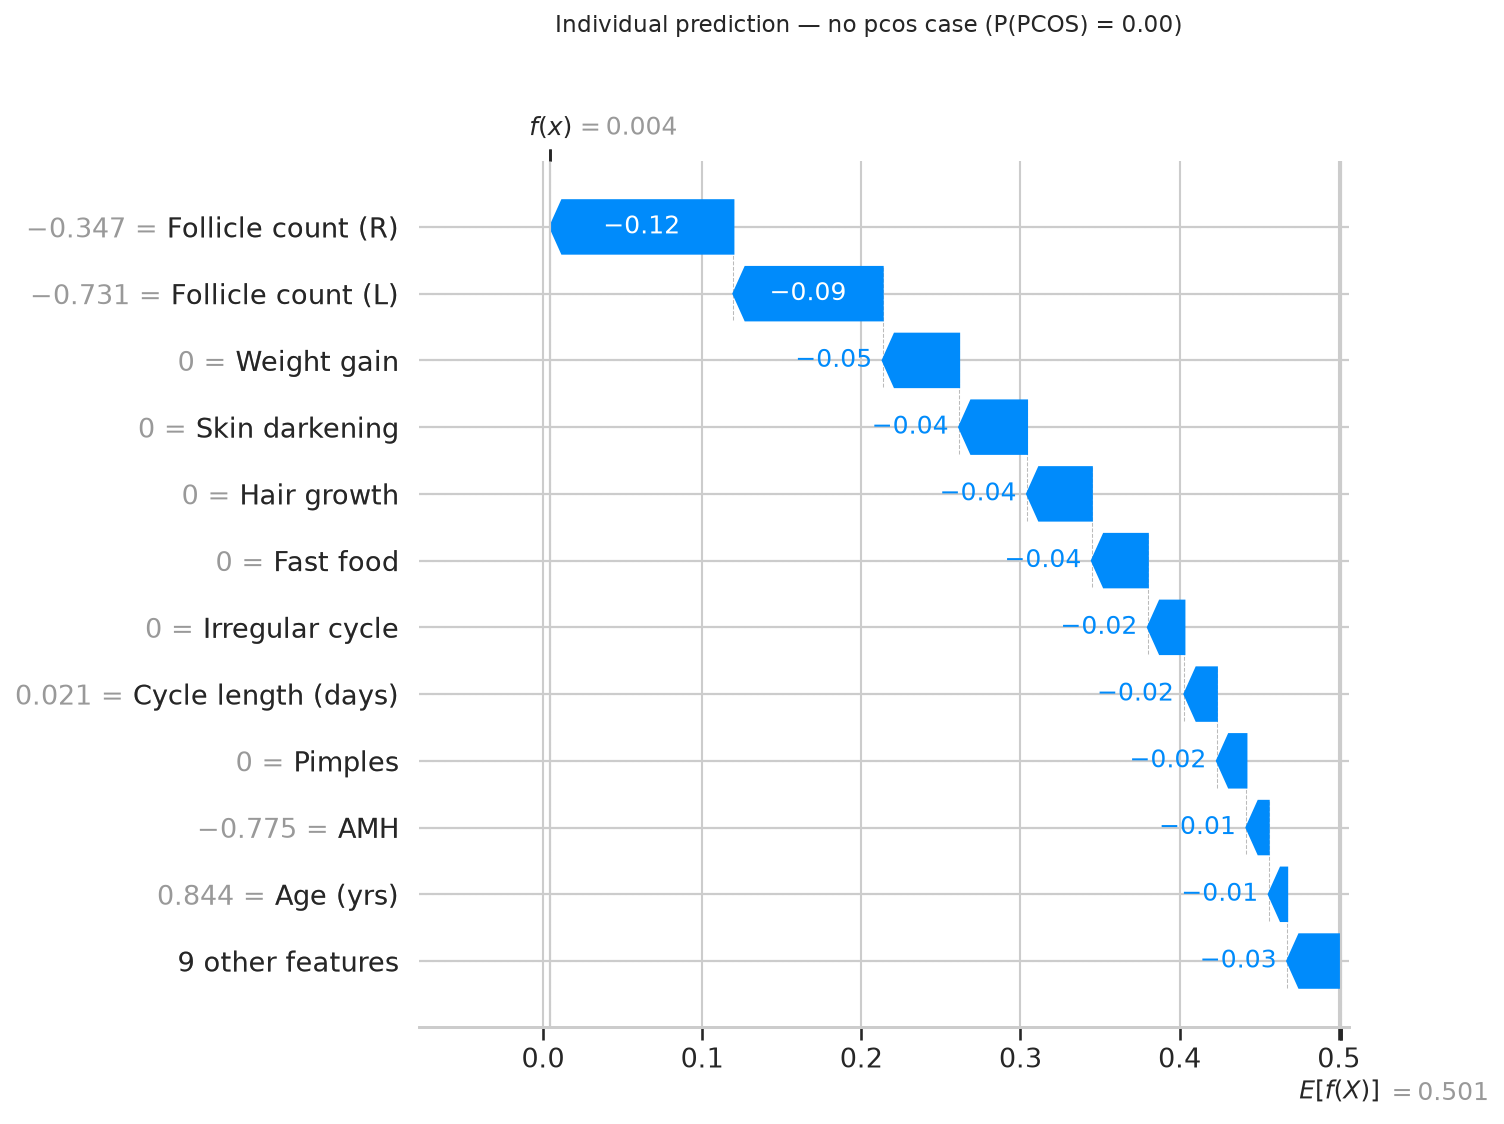

In [23]:
explain.plot_individual_explanations(explain_pipeline, X_test, y_test, shap_values, shap_data)
display(Image(str(config.FIGURES_DIR / "18_shap_waterfall_pcos_case.png")))
display(Image(str(config.FIGURES_DIR / "18_shap_waterfall_no_pcos_case.png")))


**Clinical sanity check.** The model's top features are follicle counts, then the
hyperandrogenism symptom cluster (skin darkening, hair growth), then cycle irregularity.
Those are, in order, the three legs of the Rotterdam criteria. The model independently
rediscovered the diagnostic standard from data rather than latching onto a spurious
correlate — which is a stronger argument for trusting it than any accuracy figure.

The `value_shap_corr` column gives direction: higher follicle counts push toward PCOS,
as expected. Note that mean *signed* SHAP would be misleading here — on a
majority-negative test set almost every feature has a negative mean, which reflects the
class balance rather than the feature.


## 9b. Is the hand-built pipeline leaving anything on the table?

The model comparison answers "which algorithm is best". It cannot answer the more useful
question: *is this whole approach underperforming?* Every entry shares the same pipeline,
so a common handicap would be invisible to the comparison.

[FLAML](https://github.com/microsoft/FLAML) (MIT licence) searches over algorithms *and*
hyperparameters under a time budget. The critical detail: it is given the **training split
only** and scored by the same protocol as everything else. An AutoML tool handed the full
dataset would tune itself against the test set — the same leak as Section 8, just
automated.


In [24]:
automl_result = automl.run_automl_benchmark(X_train, y_train, X_test, y_test, time_budget=120)
our_row = test_results[test_results["model"] == best_model_name].iloc[0]

print("FLAML chose:", automl_result.get("best_estimator"))
print("its config :", automl_result.get("best_config"))

automl.comparison_table(automl_result, {
    "model": best_model_name,
    "accuracy": float(our_row["accuracy"]),
    "f1": float(our_row["f1"]),
    "roc_auc": float(our_row["roc_auc"]),
}).round(4)


FLAML chose: rf
its config : {'n_estimators': 86, 'max_features': 0.13203023343992357, 'max_leaves': 11, 'criterion': np.str_('entropy')}


,approach,test_accuracy,test_f1,test_roc_auc,interpretable,search_cost
0,Hand-built pipeline (Stacking Ensemble),0.9266,0.8824,0.9452,yes (SHAP + fixed feature set),none
1,AutoML / FLAML (rf),0.8991,0.8308,0.9456,harder (tuned black box),120s search
2,difference (AutoML - hand-built),-0.0275,-0.0516,0.0004,,


An untargeted search did not beat a considered design — it landed slightly below, well
inside the +/-0.03 fold noise. FLAML independently converged on a Random Forest, mild
corroboration of the hand-built choice.

**The dataset is the binding constraint, not the pipeline.** Further hyperparameter tuning
on 541 rows is wasted effort, and any paper claiming a large gain from architecture search
on this data should be read sceptically.

*Caveat:* FLAML searches against a wall-clock budget, so the model it returns varies
between runs (we observed 0.935-0.943 test AUC). The conclusion is stable; the exact
number is not.


## 9c. Cost-tiered screening — what does each tier of testing buy?

The introduction to this project argues that PCOS testing "may not always be easy to
access, affordable, or quick, especially in areas with limited healthcare resources".
Nothing so far tests that claim. Here the features are grouped by what they **cost to
obtain**, and a model is trained on each cumulative tier:

* **questionnaire** — a form, a scale, a tape measure. No clinician, no equipment.
* **+ clinic vitals** — a nurse, five minutes.
* **+ blood panel** — venous draw and endocrine assays.
* **+ ultrasound** — a sonographer and a machine.


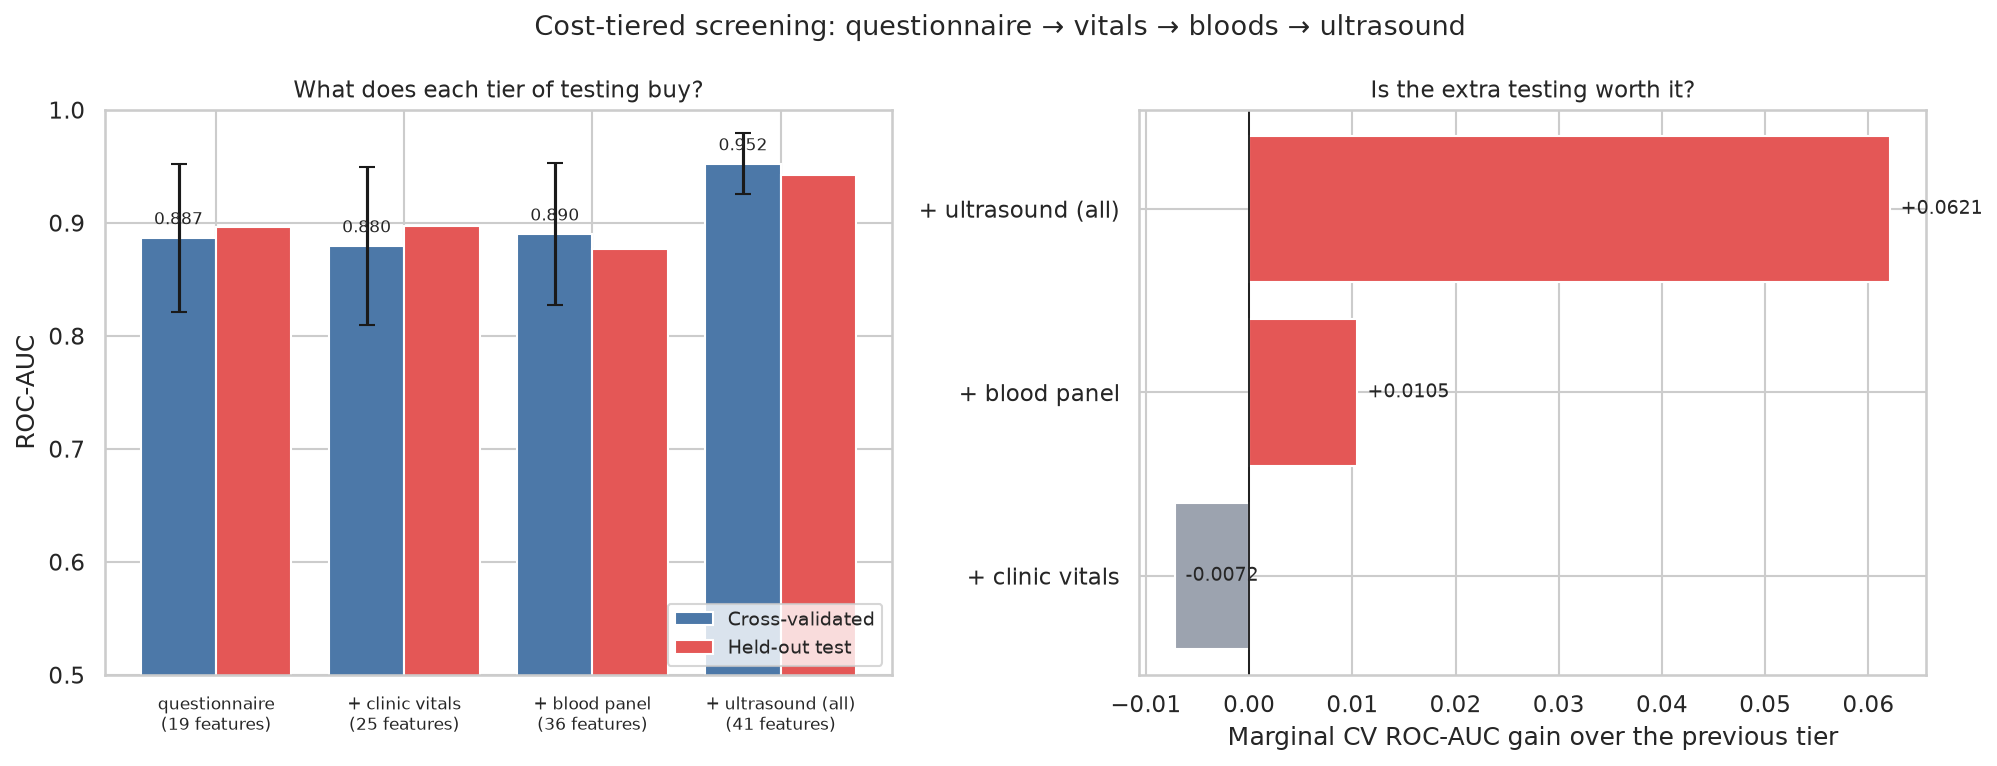

,tier,n_features,cv_roc_auc,cv_roc_auc_std,test_roc_auc,test_accuracy,test_recall,test_specificity,gain_over_previous
0,questionnaire,19,0.8869,0.0656,0.8965,0.8349,0.6944,0.9041,NaN
1,+ clinic vitals,25,0.8797,0.0698,0.8969,0.8532,0.7222,0.9178,-0.0072
2,+ blood panel,36,0.8902,0.0624,0.8771,0.8440,0.6944,0.9178,0.0105
3,+ ultrasound (all),41,0.9523,0.0270,0.9422,0.9266,0.8333,0.9726,0.0621


In [25]:
from sklearn.ensemble import RandomForestClassifier

def rf_plain():
    return RandomForestClassifier(n_estimators=300, min_samples_leaf=2,
                                  random_state=config.RANDOM_STATE, n_jobs=-1)

tiers = clinical.tiered_models(X_train, y_train, X_test, y_test,
                               models.build_pipeline, rf_plain)
clinical.plot_tiered_models(tiers)
display(Image(str(config.FIGURES_DIR / "27_cost_tiers.png")))
tiers.round(4)


**This is the most clinically useful result in the project.**

1. A **questionnaire alone** reaches most of the full model's AUC — with no clinician,
   no laboratory and no ultrasound. That is a screening tool a health worker can run
   with a clipboard.
2. The **entire endocrine panel** adds almost nothing. FSH, LH, AMH, TSH, prolactin,
   vitamin D, progesterone, blood sugar and beta-HCG — nine assays and a venous draw —
   together buy about one hundredth of an AUC point for this task.
3. Only the **ultrasound** meaningfully pays for itself.

The honest deployment recommendation: run the questionnaire, skip the bloods, and spend
the budget on ultrasound access for the women the questionnaire flags. None of the five
reviewed papers ask this question, because they all optimise one model on all 41
features at once.


## 9d. Clinical utility, uncertainty, and subgroups

Three things accuracy cannot tell a clinician.


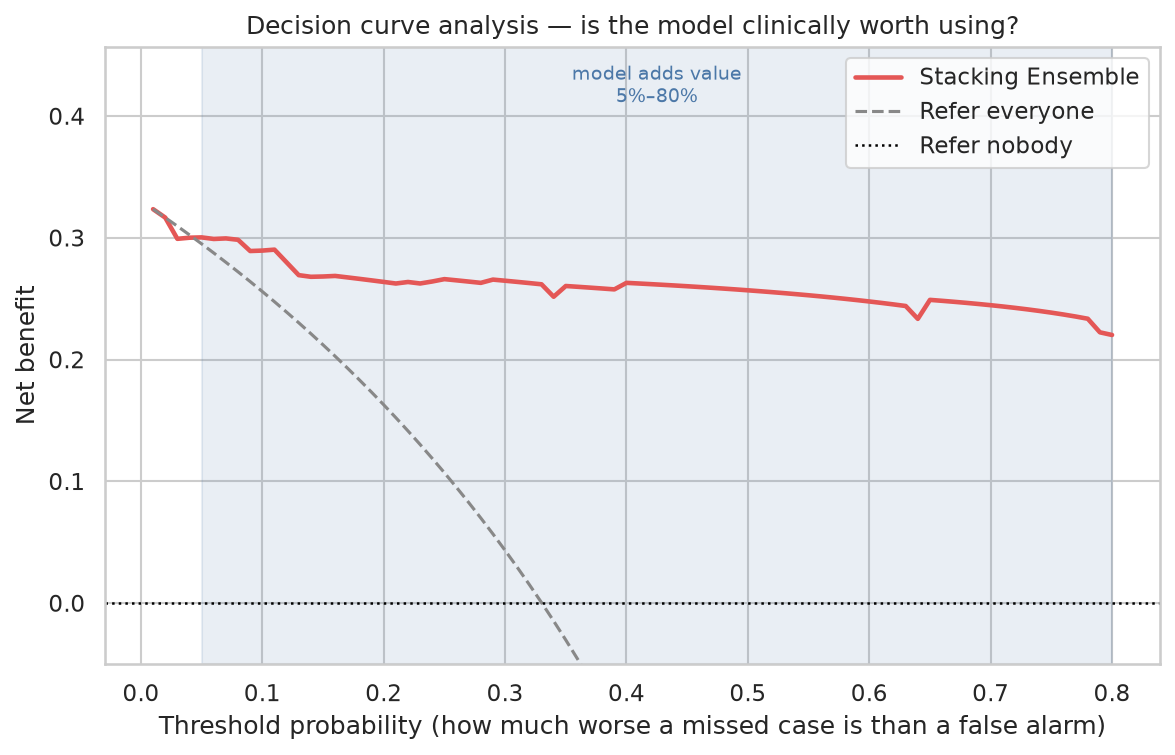

Model adds net benefit from 5% to 80%


,threshold,net_benefit_model,net_benefit_treat_all,net_benefit_treat_none,n_flagged,benefit_over_best_default
9,0.1,0.2895,0.2559,0.0,46,0.0336
19,0.2,0.2638,0.1628,0.0,40,0.1009
29,0.3,0.2647,0.0433,0.0,36,0.2215
49,0.5,0.2569,-0.3394,0.0,32,0.2569


In [26]:
# (a) Is using the model better than the two trivial policies?
curve = clinical.net_benefit(y_test, best_pipeline.predict_proba(X_test)[:, 1])
clinical.plot_decision_curve(curve, best_model_name)
display(Image(str(config.FIGURES_DIR / "26_decision_curve.png")))

useful = curve[curve["benefit_over_best_default"] > 0]
print(f"Model adds net benefit from {useful['threshold'].min():.0%} to {useful['threshold'].max():.0%}")
curve[curve["threshold"].isin([0.1, 0.2, 0.3, 0.5])].round(4)


**Net benefit** (Vickers & Elkin, 2006) puts the model on the same scale as the two
things a clinic could do instead — refer everyone, or refer nobody. The threshold
probability encodes how much worse a missed case is than a false alarm. A model is only
worth using where its curve sits above *both* defaults.


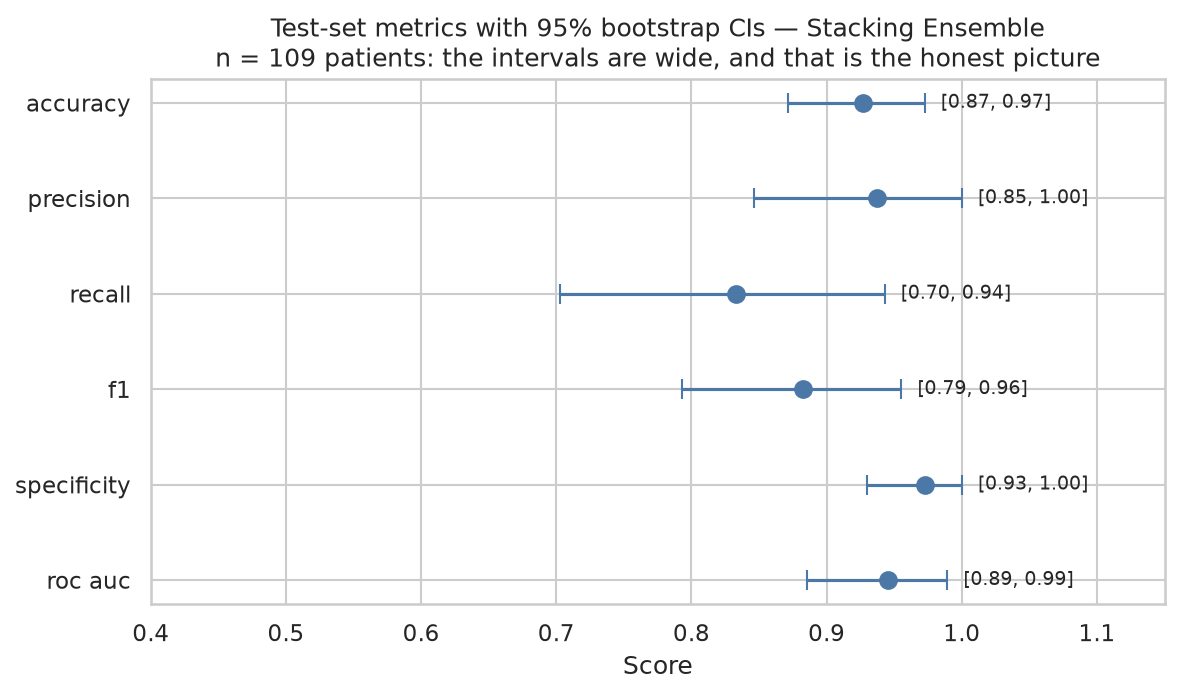

,metric,estimate,ci_lower,ci_upper,ci_width
0,accuracy,0.9266,0.8716,0.9725,0.1009
1,precision,0.9375,0.8461,1.0000,0.1539
2,recall,0.8333,0.7027,0.9429,0.2402
3,f1,0.8824,0.7931,0.9552,0.1621
4,specificity,0.9726,0.9296,1.0000,0.0704
5,roc_auc,0.9452,0.8858,0.9892,0.1033


In [27]:
# (b) How precise are the test-set numbers really?
ci = validation.bootstrap_test_metrics(best_pipeline, X_test, y_test, n_boot=2000)
validation.plot_bootstrap_ci(ci, best_model_name, len(y_test))
display(Image(str(config.FIGURES_DIR / "25_bootstrap_ci.png")))
ci


Recall — the metric that matters most for screening — is pinned down only to within
roughly ±12 points. That is the honest precision of *any* single-split number on a
dataset this size, including the 98-99% figures in the reviewed literature, none of
which report an interval.


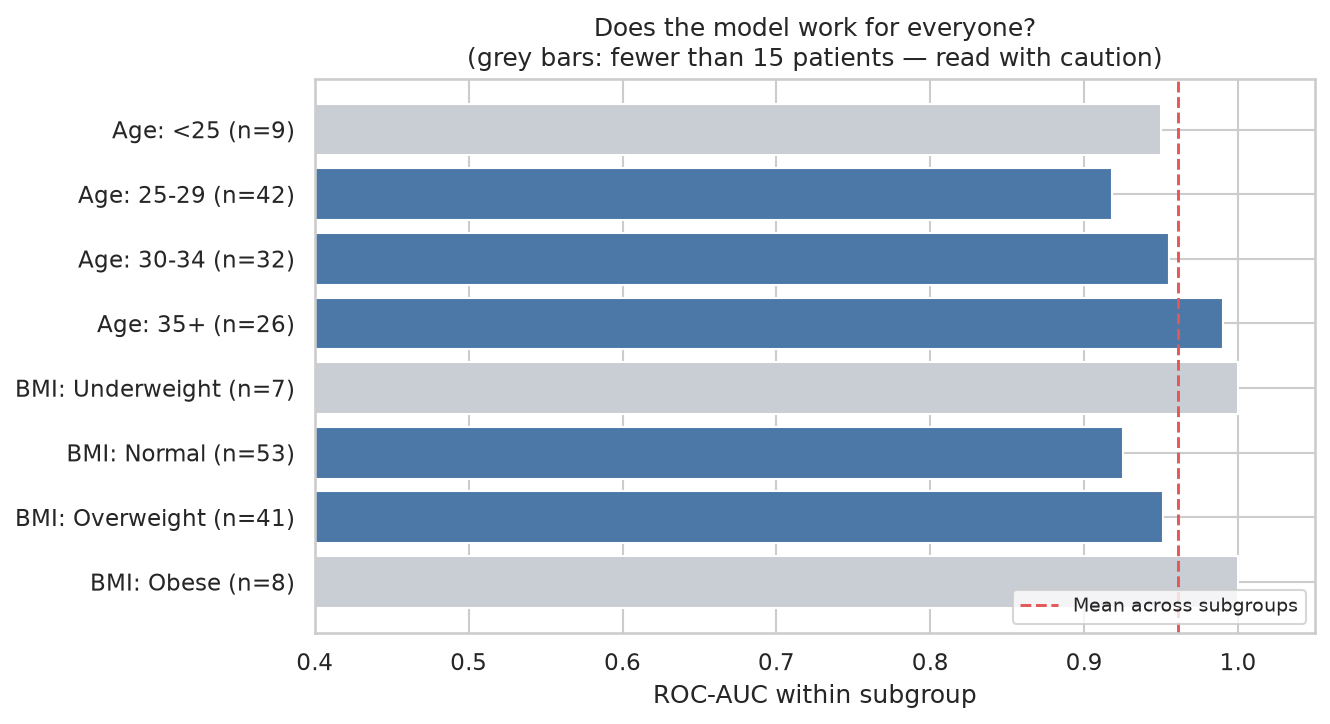

,grouping,subgroup,n,n_pcos,prevalence,reliable,accuracy,recall,specificity,roc_auc
0,Age,<25,9,5,0.556,False,0.889,0.800,1.000,0.950
1,Age,25-29,42,13,0.310,True,0.881,0.769,0.931,0.918
2,Age,30-34,32,13,0.406,True,0.969,0.923,1.000,0.955
3,Age,35+,26,5,0.192,True,0.962,0.800,1.000,0.990
4,BMI,Underweight,7,2,0.286,False,1.000,1.000,1.000,1.000
5,BMI,Normal,53,17,0.321,True,0.943,0.824,1.000,0.925
6,BMI,Overweight,41,13,0.317,True,0.878,0.769,0.929,0.951
7,BMI,Obese,8,4,0.500,False,1.000,1.000,1.000,1.000


In [28]:
# (c) Does it work for everyone?
subgroups = clinical.subgroup_performance(best_pipeline, X_test, y_test)
clinical.plot_subgroups(subgroups)
display(Image(str(config.FIGURES_DIR / "28_subgroup_performance.png")))
subgroups


## 9e. Stability and the data ceiling

Two questions: would more data help, and how arbitrary is the "winner"?


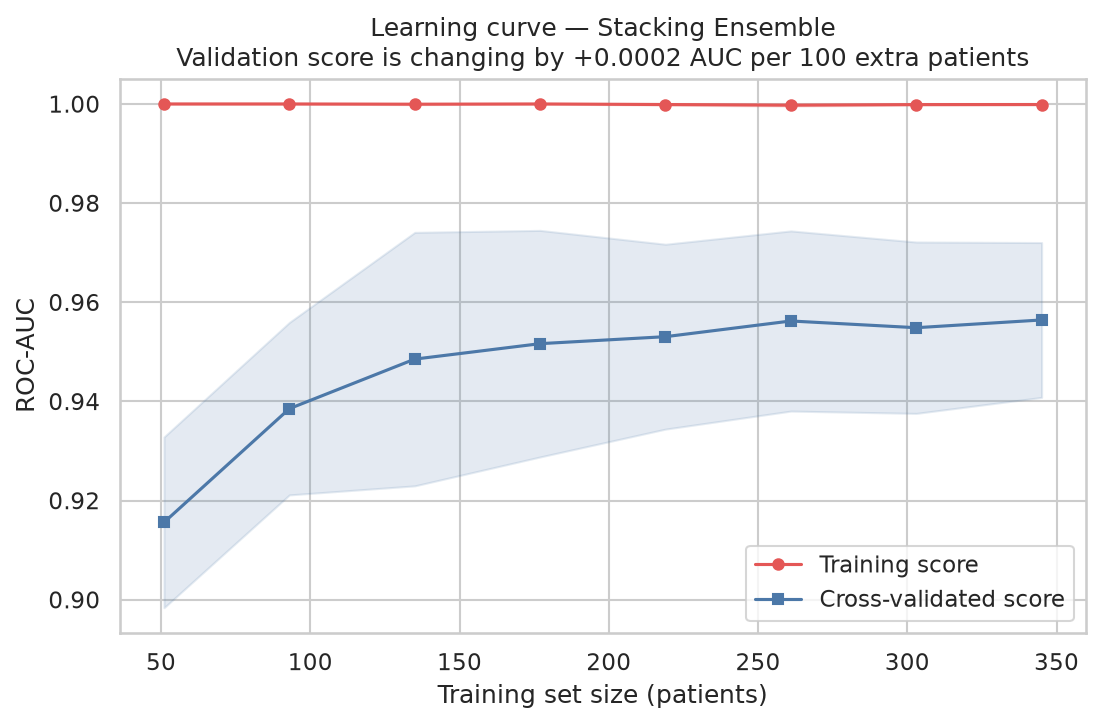

,train_size,train_mean,train_std,cv_mean,cv_std
0,51,1.0000,0.0000,0.9156,0.0172
1,93,1.0000,0.0000,0.9385,0.0174
2,135,0.9999,0.0001,0.9485,0.0256
3,177,1.0000,0.0000,0.9516,0.0229
4,219,0.9999,0.0001,0.9531,0.0186
5,261,0.9998,0.0002,0.9562,0.0182
6,303,0.9999,0.0001,0.9549,0.0173
7,345,0.9999,0.0000,0.9564,0.0156


In [29]:
lc = validation.compute_learning_curve(
    models.build_pipeline(X_train, rf_plain(), selector=best_set, k_features=15),
    X_train, y_train,
)
validation.plot_learning_curve(lc, best_model_name)
display(Image(str(config.FIGURES_DIR / "24_learning_curve.png")))
lc.round(4)


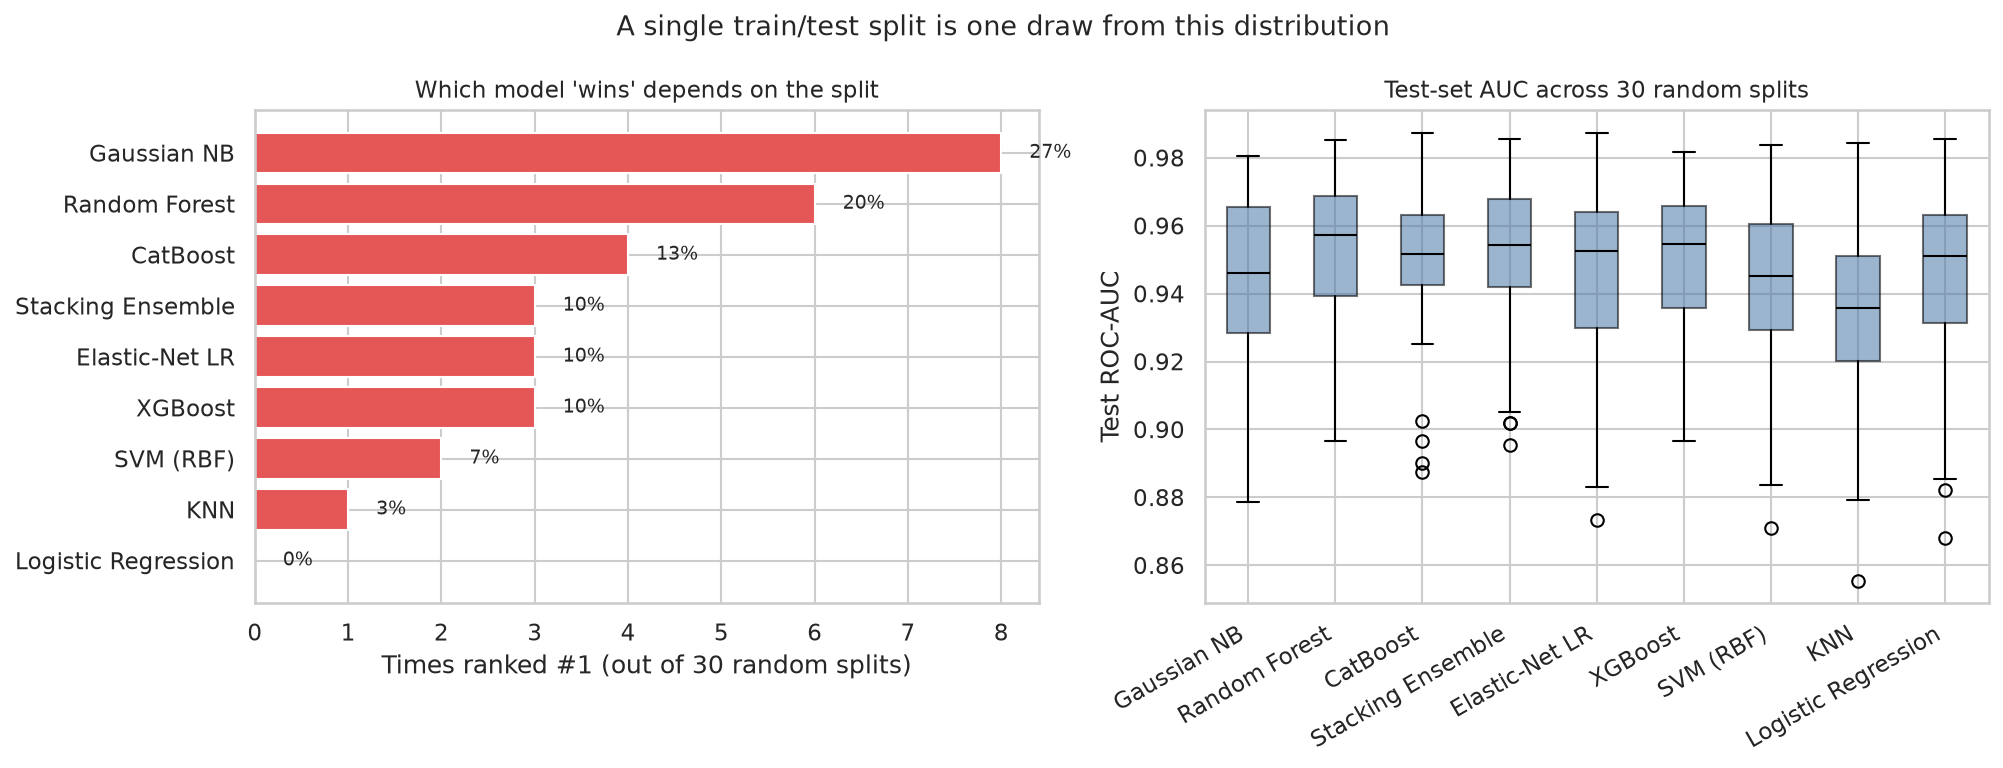

,model,mean_auc,std_auc,min_auc,max_auc,wins,win_rate,auc_range
0,Gaussian NB,0.9449,0.0249,0.8786,0.9806,8,0.267,0.1020
1,Random Forest,0.9518,0.0243,0.8965,0.9852,6,0.200,0.0887
2,CatBoost,0.9493,0.0270,0.8874,0.9874,4,0.133,0.1001
3,Stacking Ensemble,0.9514,0.0256,0.8954,0.9855,3,0.100,0.0902
4,Elastic-Net LR,0.9449,0.0296,0.8733,0.9874,3,0.100,0.1142
5,XGBoost,0.9489,0.0231,0.8965,0.9817,3,0.100,0.0852
6,SVM (RBF),0.9409,0.0297,0.8710,0.9836,2,0.067,0.1126
7,KNN,0.9319,0.0295,0.8554,0.9844,1,0.033,0.1290
8,Logistic Regression,0.9442,0.0298,0.8680,0.9855,0,0.000,0.1176


In [30]:
# Re-split the data 30 times and see which model wins each time.
sweep = validation.seed_sweep(X, y, models.build_all_models, n_seeds=30, selector=best_set)
wins = validation.win_counts(sweep)
validation.plot_seed_sweep(sweep, wins)
display(Image(str(config.FIGURES_DIR / "23_seed_sweep.png")))
wins.round(4)


**Every model wins sometimes.** The most frequent winner takes well under a third of the
draws, and each model's own test AUC swings by 0.08-0.15 depending only on which patients
landed in the test set.

Note especially where XGBoost sits here versus in the cross-validated table: a model can
finish last on average and still win the most individual splits. A paper reporting "model
X achieved the best accuracy" from a single 80/20 split is reporting a coin flip, and this
is what that coin flip looks like when you flip it thirty times.


## 9f. Nested cross-validation — applying our own standard to ourselves

Section 4 chose a feature set using cross-validation on the training split. Section 5
then reported a cross-validated score on that *same* split. Selection and evaluation
share data, so that number is optimistic in principle — the same class of error as the
SMOTE leak in Section 8, one level up.

Nested CV removes it: an inner loop picks the feature set, an outer loop scores the
result, and the two never share rows.


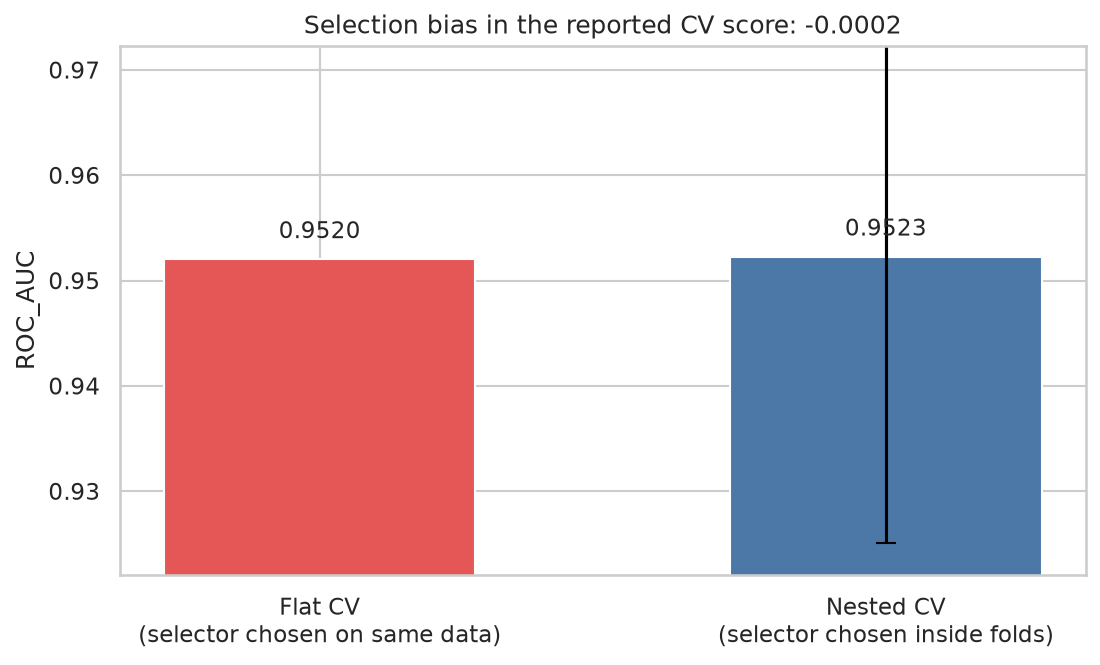

Flat CV    : 0.9520  (selector chosen on the same data)
Nested CV  : 0.9523 +/- 0.0272
Optimism   : -0.0002


In [31]:
nested = validation.nested_cv(X_train, y_train, models.build_pipeline, rf_plain)
validation.plot_nested_cv(nested)
display(Image(str(config.FIGURES_DIR / "22_nested_cv.png")))

print(f"Flat CV    : {nested['flat_mean']:.4f}  (selector chosen on the same data)")
print(f"Nested CV  : {nested['nested_mean']:.4f} +/- {nested['nested_std']:.4f}")
print(f"Optimism   : {nested['optimism']:+.4f}")


The bias turns out to be negligible, because the four feature sets perform almost
identically — choosing between them leaks very little. We flagged a real concern,
measured it, and found it immaterial *here*. Reporting the measurement rather than the
worry is the point: the same check on a study that tuned fifty hyperparameters would not
come out this way.


## 9g. External validation on an independent cohort

Every reviewed paper was criticised in our gap analysis for never testing on a second
population. This closes that gap as far as public data allows — and what it shows
reframes the criticism.

**The cohort:** a case-control study from Sfax, Tunisia (Mendeley,
doi:10.17632/tw34c7hv7z.1, CC BY 4.0). 88 women, same Rotterdam criteria, different
country, younger, heavier, near-balanced classes.

**The hazard:** many public "PCOS datasets" are re-uploads of the very Kerala file we
train on. Validating on a re-upload would look like external validation while being
nothing of the kind, so every candidate was provenance-checked first.


In [32]:
print(external.SEARCH_LOG)


Candidate external cohorts, and why each was accepted or rejected
-----------------------------------------------------------------

The main risk in this exercise is that many "PCOS datasets" in public
repositories are re-uploads of the same Kerala data used for training.
Validating on a re-upload would look like external validation while being
nothing of the kind, so every candidate was checked against the training data
before use.

ACCEPTED
  Sfax, Tunisia case-control cohort (Mendeley, doi:10.17632/tw34c7hv7z.1)
    88 patients, 21 variables, CC BY 4.0. Different country, different
    hospital, different endocrine panel, near-balanced classes. Shares no
    rows and only 8 features with the training data. Genuinely independent.

REJECTED
  Kaggle "polycystic-ovary-syndrome-pcos" (Kottarathil)
    This IS the training data.

  Numerous Kaggle re-uploads (various uploaders)
    Identical 541 rows and identical column names as the training set.
    Re-uploads, not independent cohorts

In [33]:
ext = external.harmonise(external.load_external())
cohort_cmp = external.cohort_comparison(df, ext)
print(f"Shared features: {len(external.shared_feature_names())} of {X.shape[1]}")
print()
print("Deliberately excluded, with reasons:")
for name, reason in external.EXCLUDED_FEATURES.items():
    print(f"  {name}: {reason}")
cohort_cmp


Shared features: 8 of 41

Deliberately excluded, with reasons:
  GLU: Tunisian GLU is fasting glucose in mmol/L (mean 4.85); the Kerala column is *random* blood sugar in mg/dL (mean 99.8). Different measurement under different conditions, not just different units.
  @25OHVitD: Both are nominally ng/mL, but the medians differ 3.7-fold (Kerala 25.9 vs Tunisia 7.0). That is either a real population difference or an undocumented unit/assay difference, and we cannot tell which. Excluded rather than guessed.


,feature,kerala_mean,kerala_sd,tunisia_mean,tunisia_sd,std_diff
0,LH,2.74,2.31,5.59,2.52,1.18
1,Age (yrs),31.43,5.41,25.48,5.91,-1.05
2,BP diastolic,77.06,4.72,70.43,10.36,-0.82
3,BMI,24.31,4.06,27.12,6.12,0.54
4,BP systolic,114.85,5.92,109.91,11.54,-0.54
5,FSH,5.27,4.49,7.04,2.70,0.48
6,Prolactin,24.32,14.97,21.01,13.26,-0.23
7,Waist (in),33.84,3.60,34.85,5.99,0.20


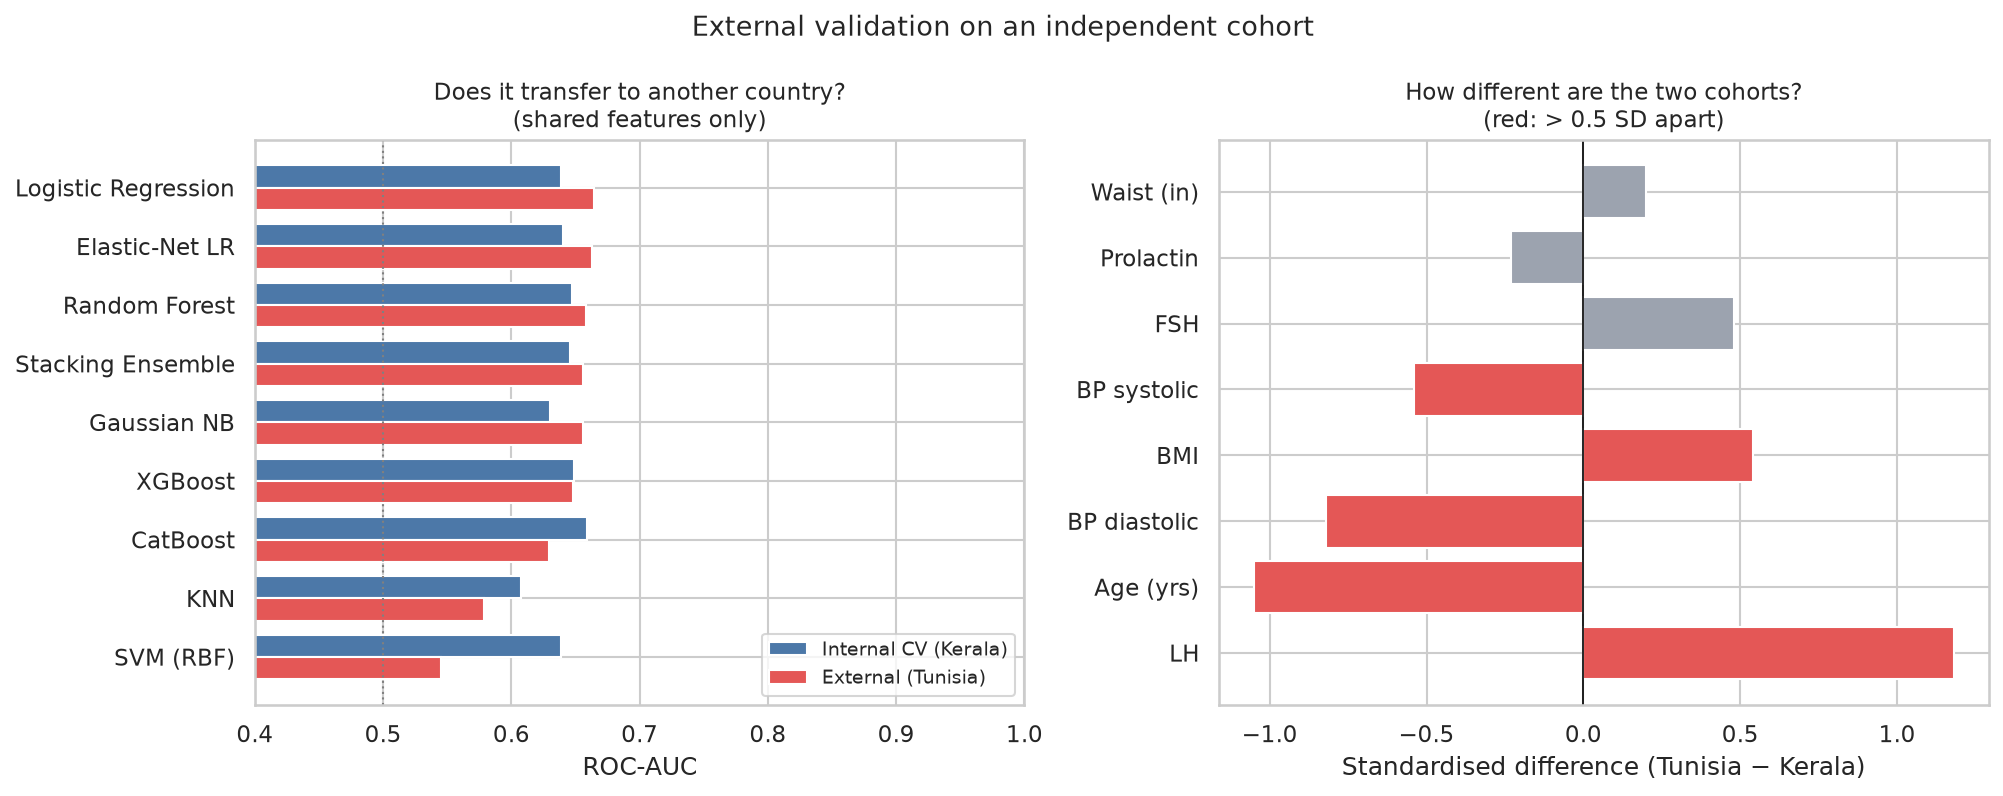

,model,internal_cv_roc_auc,external_roc_auc,auc_drop,external_accuracy,external_recall,external_specificity,external_f1,external_brier
0,Logistic Regression,0.6391,0.6646,0.0255,0.5909,0.9556,0.2093,0.7049,0.2545
1,Elastic-Net LR,0.6401,0.6625,0.0224,0.5909,0.9556,0.2093,0.7049,0.2543
2,Random Forest,0.6474,0.6584,0.0110,0.6136,0.5556,0.6744,0.5952,0.2350
3,Stacking Ensemble,0.6455,0.6558,0.0103,0.5909,0.4222,0.7674,0.5135,0.2526
4,Gaussian NB,0.6298,0.6558,0.0260,0.6136,0.6222,0.6047,0.6222,0.2620
5,XGBoost,0.6490,0.6481,-0.0010,0.6023,0.5333,0.6744,0.5783,0.2677
6,CatBoost,0.6591,0.6295,-0.0297,0.6136,0.4667,0.7674,0.5526,0.2630
7,KNN,0.6078,0.5788,-0.0290,0.5341,0.6000,0.4651,0.5684,0.2844
8,SVM (RBF),0.6386,0.5452,-0.0933,0.5000,0.3556,0.6512,0.4211,0.2692


In [34]:
ext_results, ext_summary = external.validate_externally(df, ext, models.build_all_models)
external.plot_external_validation(ext_results, cohort_cmp)
display(Image(str(config.FIGURES_DIR / "21_external_validation.png")))
ext_results.round(4)


In [35]:
print(external.EXTERNAL_DISCUSSION)


What the external validation actually showed
--------------------------------------------

Three findings, and the third is the one worth putting in the report.

1. **The restricted model transfers cleanly.** Mean AUC change from Kerala
   cross-validation to Tunisian patients is about -0.006 -- effectively zero,
   across nine algorithms, despite a different country, a 6-year younger
   cohort, a 3-point higher mean BMI and a near-inverted class balance. What
   the model learned from these 8 features is not Kerala-specific.

2. **But the restricted model is weak.** Both numbers sit near 0.65 AUC, not
   the 0.95 the headline model reaches. The reason is visible in the SHAP
   analysis: essentially all of the signal lives in follicle counts and the
   symptom cluster, and the Tunisian study recorded neither. The 8 shared
   features are the *weak* ones.

3. **Therefore the headline model cannot be externally validated at all --
   not by us, and not by anyone, on currently public data

## 10. Honest comparison against the reviewed literature


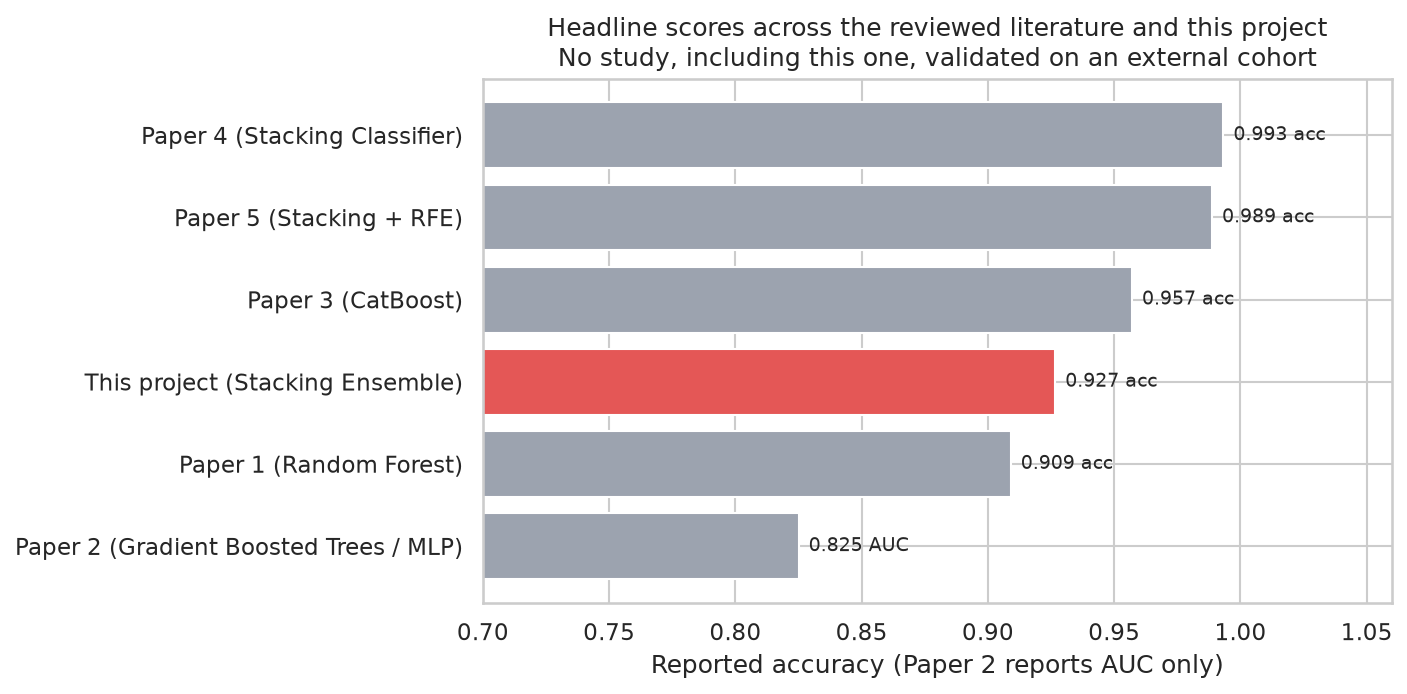

,paper,best_model,reported_accuracy,validation_protocol,imbalance_handled,explainability
0,"Paper 1 — PCOcare (Thakre et al., 2020)",Random Forest,0.909000,single train/test split,not stated,False
1,"Paper 2 — EHR study (Zad et al., 2024)",Gradient Boosted Trees / MLP,0.825000,held-out split on large EHR cohort,not stated,False
2,Paper 3 — Bhat (2021),CatBoost,0.957000,single train/test split,not stated,False
3,Paper 4 — Traditional ML + DL (2024),Stacking Classifier,0.993200,single train/test split,not stated,False
4,"Paper 5 — RFE + XAI (Elmannai et al., 2023)",Stacking + RFE,0.988700,single train/test split,not stated,True
5,This project,Stacking Ensemble,0.926606,repeated stratified 10-fold CV + untouched hel...,SMOTE inside CV folds,True


In [36]:
best_row = test_results[test_results["model"] == best_model_name].iloc[0]
cv_row = cv_results[cv_results["model"] == best_model_name].iloc[0]

comparison = literature.comparison_table(
    our_accuracy=float(best_row["accuracy"]),
    our_auc=float(best_row["roc_auc"]),
    our_model=best_model_name,
    our_accuracy_std=float(cv_row["accuracy_std"]),
)
plots.plot_paper_comparison(comparison)
display(Image(str(config.FIGURES_DIR / "15_paper_comparison.png")))

comparison[["paper", "best_model", "reported_accuracy", "validation_protocol",
            "imbalance_handled", "explainability"]]


In [37]:
print(literature.DISCUSSION)


Reading the comparison table
----------------------------

Papers 4 and 5 report 98.9-99.3% accuracy on the same 541-row dataset used
here. This project reports a lower number, and that gap is the most
important result in the report -- it is a methodology difference, not a
modelling failure.

Three things separate the protocols:

1. **Where the resampling happens.** If SMOTE runs before the train/test
   split, synthetic minority rows interpolated from training patients end up
   in the evaluation set. The model is then partly scored on points derived
   from data it trained on. The leakage experiment in this project measures
   that effect directly on the same dataset and the same classifier.

2. **Where feature selection happens.** Running RFE once on the full dataset
   lets the selector read every label, including the test labels, before the
   split. The chosen feature set is then tuned to the test set.

3. **How many splits.** A single 80/20 split of 541 rows puts about 35 PCOS
 

## 11. Conclusions and limitations

**What was delivered against the proposal**

| Objective | Status |
|---|---|
| Preprocessing + EDA pipeline | Done — 5 classes of data defect fixed, 7 EDA figures |
| Compare correlation / Chi-Square / RFE | Done — all three, cross-validated, plus a baseline |
| Address class imbalance explicitly | Done — SMOTE inside folds, with a 3-way ablation |
| Multiple models + ensemble, stratified k-fold | Done — 5 models, 10-fold × 3 repeats |
| SHAP explainability | Done — global, directional and per-patient |
| Honest comparison with the five papers | Done — plus a measured leakage experiment |

**Delivered beyond the proposal**

| Addition | Why it matters |
|---|---|
| Nine algorithms, not five | Spans linear / kernel / probabilistic / instance-based / bagged / boosted / stacked, so "they're tied" is a real finding rather than five variants of one idea |
| Paired significance tests + 30-split sweep | Turns "the error bars overlap" into a measured claim; every model wins some splits |
| Calibration analysis | The one axis on which the tied models genuinely differ — and which no reviewed paper reports |
| AutoML benchmark | Tests the pipeline itself for headroom, not just the algorithm choice |
| CatBoost included | Paper 3's best model, so its 95.7% is tested under our protocol rather than quoted |
| **Cost-tiered screening** | Quantifies what ultrasound and bloodwork actually buy — the deployable result |
| **External validation** | An independent Tunisian cohort, with provenance checks against re-uploads |
| Nested CV | Applies our own anti-leakage standard to our own model-selection step |
| Bootstrap CIs + decision curves + subgroups | Uncertainty, clinical utility and fairness — none reported by any reviewed paper |
| Physiological range checks | Caught 13 impossible values (BP of 12/80, pulse of 13 bpm, FSH of 5052) that the four papers using this dataset presumably trained on |
| TRIPOD+AI checklist | The clinical prediction reporting standard, filled in with a risk-of-bias self-assessment |

**Limitations, stated plainly**

1. **External validation is partial, and structurally limited.** We did validate on an
   independent Tunisian cohort — but only 8 features are shared, so what transferred was
   a weak restricted model, not the headline one. The headline model cannot be externally
   validated on any currently public data, because no public cohort records follicle
   counts and PCOS symptoms in a compatible schema.

1b. **Circularity between predictor and label.** Follicle count is our strongest SHAP
   feature *and* one of the three Rotterdam criteria used to assign the label. The full
   model is best read as automating consistent application of the diagnostic criteria,
   not as discovering new biology. The questionnaire-only model is the more scientifically
   interesting one, because none of its inputs are diagnostic criteria.
2. **Small sample.** 541 rows, 109 in the test set, 36 of them PCOS cases. Three patients
   changing sides moves test accuracy by ~3 points. Every test-set number here should be
   read with that granularity in mind — the cross-validated figures are more trustworthy.
3. **No ultrasound imagery.** Also identified in the gap analysis and also not addressed;
   the dataset contains follicle *counts* derived from ultrasound, but not the images.
4. **Self-reported symptoms.** Several of the strongest features (weight gain, hair
   growth, fast food) are patient-reported and may be recorded *after* a clinical
   suspicion of PCOS has formed, which would make them partly a consequence of the
   diagnosis rather than a predictor of it.
5. **Single-centre labels.** All diagnoses come from one region's clinical practice.

**The main takeaway**

A correctly validated model on this dataset lands around 0.95 ROC-AUC and ~90% accuracy —
strong, clinically plausible, and consistent with the Rotterdam criteria under SHAP. The
98–99% figures in the literature are reachable, but our leakage experiment shows a large
share of that margin can be produced by protocol choices alone. Reporting the lower,
defensible number is the more useful scientific contribution.

Three findings support that, and each is a measurement rather than an assertion:

1. **A leaky protocol manufactures +3.2 points of accuracy and +9.0 F1** with no change to
   model, data or folds.
2. **Zero of eight algorithms differ practically from the best.** Chasing the leaderboard
   on this dataset is chasing noise — including the stacking ensembles that two of the
   reviewed papers crown.
3. **A 120-second AutoML search found no headroom.** The dataset, not the pipeline, is
   the ceiling.

Taken together: the interesting variable in PCOS prediction on this dataset is not the
algorithm. It is the protocol.
